# **Ola Driver Churn Analysis**

## **Problem Statement**

Retaining drivers is one of the key challenges faced by Ola. Drivers may leave the platform for various reasons, such as better earning opportunities, lack of growth, or dissatisfaction with their overall experience. High driver attrition not only increases recruitment and onboarding costs but can also impact service availability and business performance.

The goal of this project is to analyse driver data from 2019 and 2020 to understand the factors associated with driver attrition and build a predictive model that can identify drivers who are at risk of leaving the platform. The insights generated from this analysis can help Ola develop targeted strategies to improve driver retention and reduce churn.


## **Executive Summary**

The aim of this project was to understand why drivers leave the Ola platform and build a model capable of identifying drivers who are at risk of churn.

The analysis was performed on 19,104 monthly driver records collected during 2019 and 2020. Since the objective was to predict churn at the driver level, the data was aggregated into 2,381 unique driver profiles before modelling.

Exploratory analysis was carried out to understand driver demographics, earnings, performance, business value, and churn patterns. Additional features such as Tenure, Income Growth, Rating Growth, Grade Progression, and Primary City were created to better represent driver behaviour over time.

A Logistic Regression model was developed to predict driver churn. To address class imbalance, a baseline class-weighted model was compared with a SMOTE-based model. Since the baseline model delivered better overall performance, it was selected as the final model.

### Model Performance

* Recall (Churn): 86%
* Precision (Churn): 85%
* F1-Score (Churn): 85%
* ROC-AUC: 0.851

### Key Findings

* Total Business Value was the strongest indicator of driver retention.
* Drivers whose ratings improved over time were less likely to churn.
* Higher-income drivers showed better retention.
* Churn was highest among drivers with approximately 7-16 months of tenure before declining for long-tenured drivers.
* Performance-related factors showed stronger relationships with churn than demographic characteristics.

### Business Recommendations

* Improve earning opportunities through incentives and reward programs.
* Recognise and retain high-performing drivers through targeted engagement initiatives.
* Provide additional support to drivers generating lower business value.
* Focus retention efforts on drivers in the mid-tenure stage, where churn risk is highest.

The findings from this analysis can help Ola identify at-risk drivers early and implement targeted retention strategies to reduce driver churn.


# **Table of Contents**

### 1. Data Loading & Understanding

* Importing Libraries
* Loading Dataset and Initial Preview
* Initial Exploration
* Missing Values Analysis
* Initial Understanding

### 2. Exploratory Data Analysis (EDA)

#### 2.1 Univariate Analysis

* Target Variable (Churn Flag)
* Class Imbalance Analysis
* Outlier Detection
* Age Distribution
* Income Distribution
* Total Business Value
* Log Transformation
* Quarterly Rating
* Education Level
* Driver Distribution by City

#### 2.2 Exploratory Relationship Analysis

#### 2.3 Targeted Bivariate Analysis

* Quarterly Rating vs Churn
* Income vs Churn
* Total Business Value vs Churn
* Grade vs Churn
* Age vs Churn
* City vs Churn

### 3. Temporal Analysis

* Driver Joining & Leaving Trends
* Average Driver Tenure

### 4. Transition to Feature Engineering

### 5. Feature Engineering

* Driver-Level Dataset Creation
* Driver Aggregation
* Tenure
* Income Growth
* Rating Growth
* Grade Progression
* Primary City

### 6. Feature Validation & Dataset Review

* Target Variable Validation

### 7. Additional Relationship Analysis

* Age vs Latest Income
* Education Level vs Total Business Value
* Primary City vs Total Business Value
* Quarterly Rating vs Total Business Value

### 8. Multicollinearity Analysis

* Feature Correlation Heatmap
* VIF Analysis
* Final Multicollinearity Assessment

### 9. Model Preparation

* Modelling Dataset Creation
* Feature Selection
* Primary City Encoding
* Defining Features and Target Variable

### 10. Model Development

* Baseline Logistic Regression
* Prediction Generation
* Model Evaluation

  * Confusion Matrix
  * Classification Report
  * ROC-AUC Score
  * ROC Curve
* Feature Importance Analysis
* Additional Driver Tenure Observation

### 11. Model Improvement Using SMOTE

* SMOTE Training
* Model Evaluation
* Feature Importance Analysis
* Final Model Selection

### 12. Business Recommendations

### 13. Conclusion


# **1. Data Understanding**

### **Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### **Loading Dataset and Initial Preview**

In [ ]:
#loading of dataset
df=pd.read_csv("/content/ola_driver.csv")
#initial Preview
df.head(5)

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


### **Initial Exploration**

In [ ]:
#structure of the data
df.shape

(19104, 14)

In [ ]:
#columns
df.columns

Index(['Unnamed: 0', 'MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City',
       'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate',
       'Joining Designation', 'Grade', 'Total Business Value',
       'Quarterly Rating'],
      dtype='object')

In [ ]:
#dropping unnecessary column
df.drop(columns=['Unnamed: 0'],inplace=True)

In [ ]:
#Checking the Data Types of Columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MMM-YY                19104 non-null  object 
 1   Driver_ID             19104 non-null  int64  
 2   Age                   19043 non-null  float64
 3   Gender                19052 non-null  float64
 4   City                  19104 non-null  object 
 5   Education_Level       19104 non-null  int64  
 6   Income                19104 non-null  int64  
 7   Dateofjoining         19104 non-null  object 
 8   LastWorkingDate       1616 non-null   object 
 9   Joining Designation   19104 non-null  int64  
 10  Grade                 19104 non-null  int64  
 11  Total Business Value  19104 non-null  int64  
 12  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 1.9+ MB


Notice here that Date Columns such as MMM-YY, Dateofjoining,LastWorkingDate are represented in the wrong data type

In [ ]:
#datatypeconversion
# Monthly reporting date
df['MMM-YY'] = pd.to_datetime(
    df['MMM-YY'],
    format='%m/%d/%y'
)

# Driver joining date
df['Dateofjoining'] = pd.to_datetime(
    df['Dateofjoining'],
    format='%d/%m/%y'
)

# Driver exit date
df['LastWorkingDate'] = pd.to_datetime(
    df['LastWorkingDate'],
    format='%d/%m/%y',
    errors='coerce'
)

In [ ]:
df[['MMM-YY','Dateofjoining','LastWorkingDate']].head(5)

,MMM-YY,Dateofjoining,LastWorkingDate
0,2019-01-01,2018-12-24,NaT
1,2019-02-01,2018-12-24,NaT
2,2019-03-01,2018-12-24,2019-11-03
3,2020-11-01,2020-06-11,NaT
4,2020-12-01,2020-06-11,NaT


### **Missing Values Analysis**

In [ ]:
df.isna().sum()

,0
MMM-YY,0
Driver_ID,0
Age,61
Gender,52
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488
Joining Designation,0


* Upon initial exploration, missing values were observed in the Age, Gender, and LastWorkingDate columns.

* For LastWorkingDate, missing values are expected and meaningful because they indicate drivers who are currently active and have not left the company.

* For Age and Gender, further inspection showed that the dataset contains monthly records for the same driver (Driver_ID). In several cases, these demographic values were available in some months but missing in others for the same driver.

* Since Age and Gender are driver-level attributes and generally remain consistent over time, global imputation methods such as mean or median filling would not be appropriate. Therefore, missing values were imputed using existing information from the same driver group (Driver_ID) to preserve data consistency and business validity.

In [ ]:
# Fill Age using driver's own median age
df['Age'] = df.groupby('Driver_ID')['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Fill Gender using driver's own mode gender
df['Gender'] = df.groupby('Driver_ID')['Gender'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

In [ ]:
df.isna().sum()

,0
MMM-YY,0
Driver_ID,0
Age,0
Gender,0
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488
Joining Designation,0


* Missing values in Age and Gender were significantly reduced using driver-wise imputation. This approach ensured that demographic consistency was maintained across monthly records belonging to the same driver.

* For LastWorkingDate Column, missing values are expected and meaningful because they indicate drivers who are currently active and have not left the company. Therefore we create a churn flag column which indicates that driver has churned or still active in company

In [ ]:
#churnflagcolumn
df['churn_flag'] = np.where(df['LastWorkingDate'].isna(), 0, 1)

### **Initial Understanding**

In [ ]:
#statistical summary of Numerical Column
df.describe()

,MMM-YY,Driver_ID,Age,Gender,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,churn_flag
count,19104,19104.000000,19104.000000,19104.000000,19104.000000,19104.000000,19104,1616,19104.000000,19104.000000,1.910400e+04,19104.000000,19104.000000
mean,2019-12-11 02:09:29.849246464,1415.591133,34.650518,0.418813,1.021671,65652.025126,2018-04-20 21:49:17.788944896,2019-12-26 23:22:34.455445760,1.690536,2.252670,5.716621e+05,2.008899,0.084590
min,2019-01-01 00:00:00,1.000000,21.000000,0.000000,0.000000,10747.000000,2013-01-04 00:00:00,2018-12-31 00:00:00,1.000000,1.000000,-6.000000e+06,1.000000,0.000000
25%,2019-06-01 00:00:00,710.000000,30.000000,0.000000,0.000000,42383.000000,2016-11-28 00:00:00,2019-06-10 00:00:00,1.000000,1.000000,0.000000e+00,1.000000,0.000000
50%,2019-12-01 00:00:00,1417.000000,34.000000,0.000000,1.000000,60087.000000,2018-09-19 00:00:00,2019-12-20 12:00:00,1.000000,2.000000,2.500000e+05,2.000000,0.000000
75%,2020-07-01 00:00:00,2137.000000,39.000000,1.000000,2.000000,83969.000000,2019-10-25 00:00:00,2020-07-14 00:00:00,2.000000,3.000000,6.997000e+05,3.000000,0.000000
max,2020-12-01 00:00:00,2788.000000,58.000000,1.000000,2.000000,188418.000000,2020-12-28 00:00:00,2020-12-28 00:00:00,5.000000,5.000000,3.374772e+07,4.000000,1.000000
std,NaN,810.705321,6.264563,0.493378,0.800167,30914.515344,NaN,NaN,0.836984,1.026512,1.128312e+06,1.009832,0.278277


* The statistical summary of numerical variables provides an initial understanding of the dataset distribution, spread, and potential anomalies.

* Several features such as Income and Total Business Value show noticeable differences between mean and median values, suggesting possible skewness and the presence of outliers.

* In particular, Total Business Value exhibits a very large range between minimum and maximum values, indicating extreme variations in driver business performance. Additionally, negative business values are present, which may correspond to cancellations, refunds, or EMI adjustments as described in the business documentation.

* Variables such as Age appear relatively stable with reasonable ranges, while categorical-encoded numerical columns like Gender, Education_Level, Grade, and Quarterly Rating require frequency-based exploration rather than relying solely on statistical summaries.

Therefore, further univariate analysis and visual exploration will be performed to:

* understand feature distributions

* detect skewness

* identify potential outliers

* interpret business behaviour across different driver attributes

# **2. Exploratory Data Analysis (EDA)**

## **2.1 Univariate Analysis**

### **A. Target Variable (churn_flag)**

#### **Class Imbalance Analysis**

In [ ]:
df['churn_flag'].value_counts()

,count
churn_flag,
0,17488
1,1616


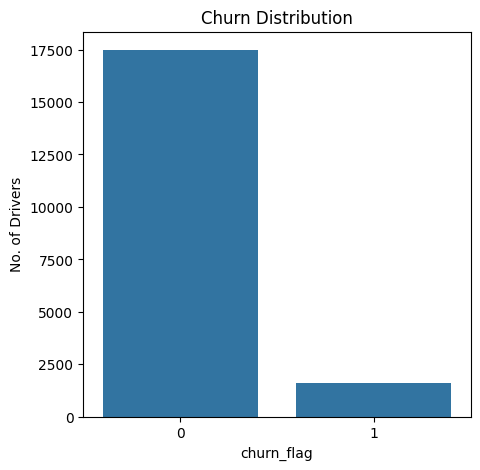

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(x='churn_flag', data=df)
plt.title("Churn Distribution")
plt.ylabel("No. of Drivers")
plt.show()

In [ ]:
round((df['churn_flag'].value_counts(normalize=True))*100,2)

,proportion
churn_flag,
0,91.54
1,8.46


The target variable shows significant class imbalance, with approximately 91.5% active drivers and only 8.5% churned drivers. This imbalance should be considered during predictive model development to avoid biased predictions toward the majority class.

**Possible Techniques to Overcome Class Imbalance of Target Variable(churn_flag):-**

* SMOTE (Synthetic Minority Oversampling Technique) can also be used to generate synthetic samples for the minority churn class and improve class balance.
* However, for this analysis, class-weight balancing is preferred to maintain workflow simplicity and model interpretability.

### **Outlier Detection**

### **B. Age Distribution**

**Histogram**

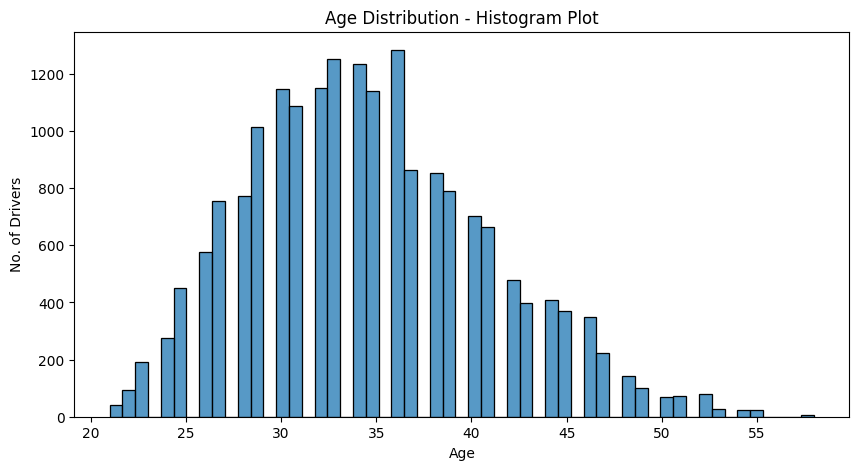

In [ ]:
#histogram plot
plt.figure(figsize=(10,5))
sns.histplot(df['Age'])
plt.title("Age Distribution - Histogram Plot")
plt.ylabel("No. of Drivers")
plt.show()

**KDE (Kernal Density Estimate) Plot**

Another useful plot is called the 'density' plot. Which is also similar to histogram, but with a more approximate shape. It tries to fit a suitable distribution over the histogram and hence includes points that might not even be present in data at hand.

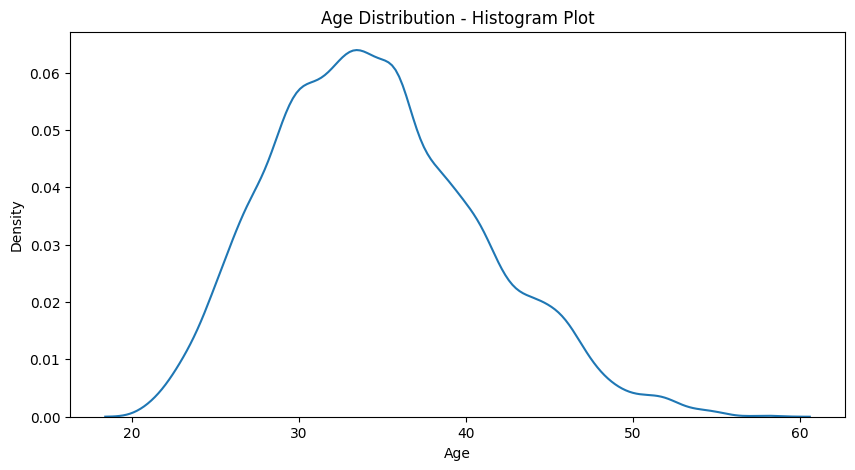

In [ ]:
plt.figure(figsize=(10,5))
sns.kdeplot(df['Age'])
plt.title("Age Distribution - Histogram Plot")
plt.show()

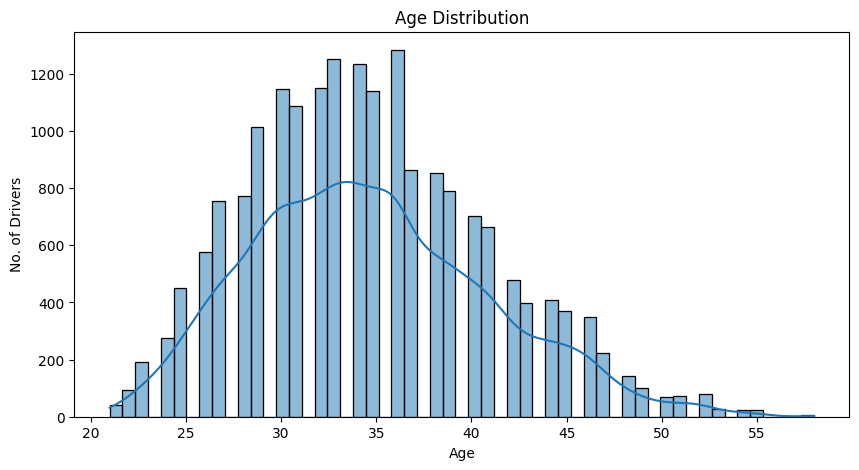

In [ ]:
# Combined Plot (HISTOGRAM + KDE PLOT)
plt.figure(figsize=(10,5))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.ylabel("No. of Drivers")
plt.show()

**Box Plot**

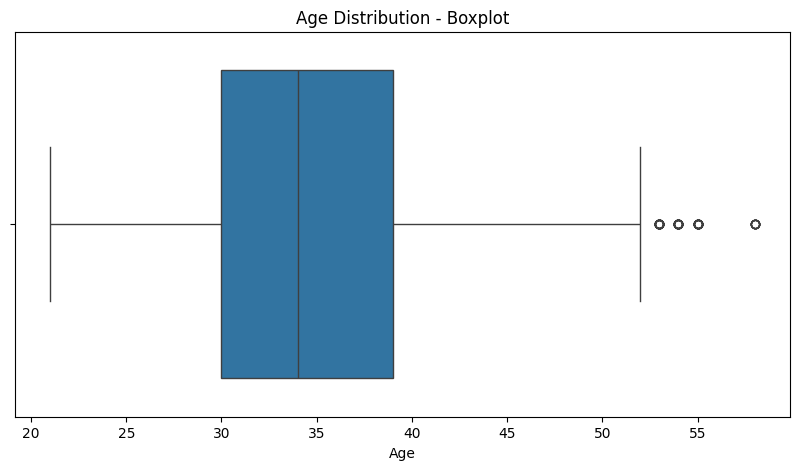

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Age'])
plt.title("Age Distribution - Boxplot")
plt.show()

**IQR (Inter Quartile Range) Technique**

In [ ]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

age_outliers = df[
    (df['Age'] < lower_bound) |
    (df['Age'] > upper_bound)
]

print("Number of outliers:", age_outliers.shape[0])

print(f"outlier percentage:- {round((age_outliers.shape[0] / df.shape[0]) * 100,2)}%")


Number of outliers: 79
outlier percentage:- 0.41%


* The age distribution of drivers appears approximately bell-shaped with a slight positive skew toward higher age groups.

* Most drivers fall within the age range of 30–40 years, indicating that the platform is largely dominated by middle-aged drivers.

* Boxplot analysis and IQR-based outlier detection identified a small number of upper-end age outliers beyond the upper whisker. However, these observations fall within realistic human age ranges and likely represent older-generation drivers rather than data quality issues.

* Therefore, these outliers were retained for further analysis since they may still carry meaningful business information.

### **C. Income Distribution**



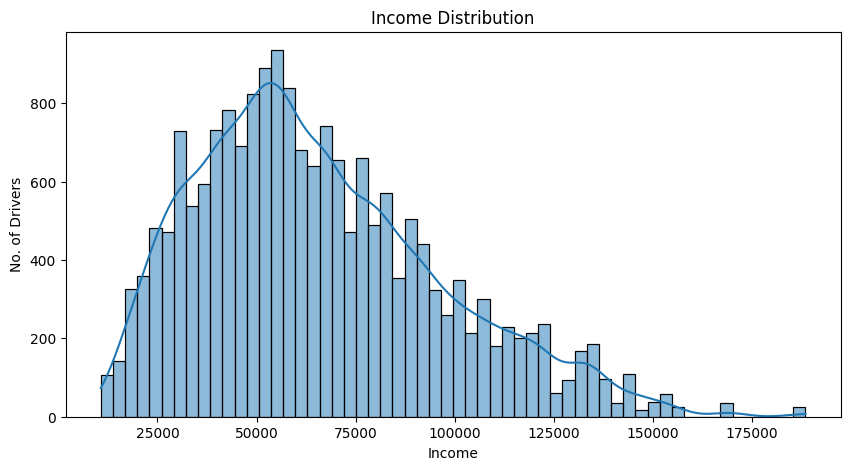

In [ ]:
# Combined Plot (HISTOGRAM + KDE PLOT)
plt.figure(figsize=(10,5))
sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.ylabel("No. of Drivers")
plt.show()

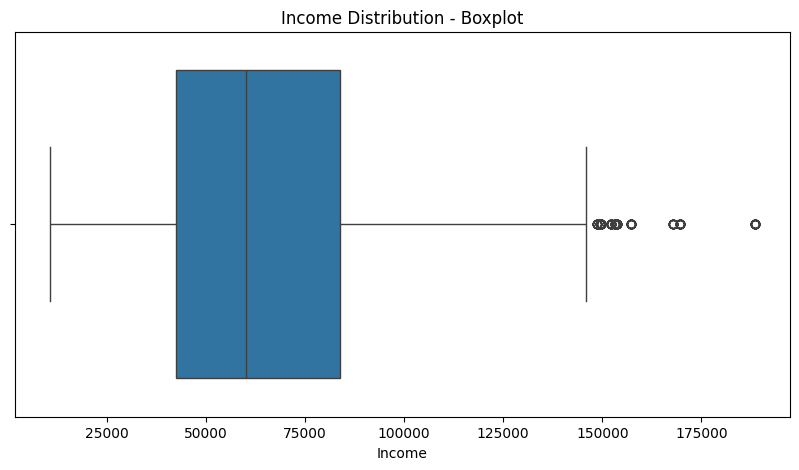

In [ ]:
#boxplot
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Income'])
plt.title("Income Distribution - Boxplot")
plt.show()


In [ ]:
#IQR
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

income_outliers = df[
    (df['Income'] < lower_bound) |
    (df['Income'] > upper_bound)
]

print("Number of outliers:", income_outliers.shape[0])
print(f"outlier percentage:- {round((income_outliers.shape[0] / df.shape[0]) * 100,2)}%")


Number of outliers: 188
outlier percentage:- 0.98%


* The Income variable exhibits a positively skewed distribution, indicating that while the majority of drivers earn within a moderate income range, a small proportion of drivers earn substantially higher incomes.

* Boxplot and IQR analysis identified approximately 0.98% of records as upper-end outliers. However, these observations remain within plausible business limits and may represent high-performing drivers benefiting from factors such as increased trip frequency, longer ride distances, peak-hour incentives, or operation within high-demand regions.

* Although the maximum income is nearly three times the median income, the relatively low proportion of extreme observations suggests that these are more likely business-driven variations rather than direct data quality issues.

* Therefore, these outliers were retained for further analysis as they may contain valuable insights regarding high-performing driver segments.

### **D. Total Business Value**



* Initial statistical exploration indicates that Total Business Value has a significant gap between the mean and median values, suggesting the presence of strong positive skewness and potential extreme outliers.

* The column also contains large negative values, which likely correspond to cancellations, refunds, or EMI adjustments as described in the business documentation.

* Therefore, further visual analysis is required to better understand the distribution pattern and outlier behaviour.

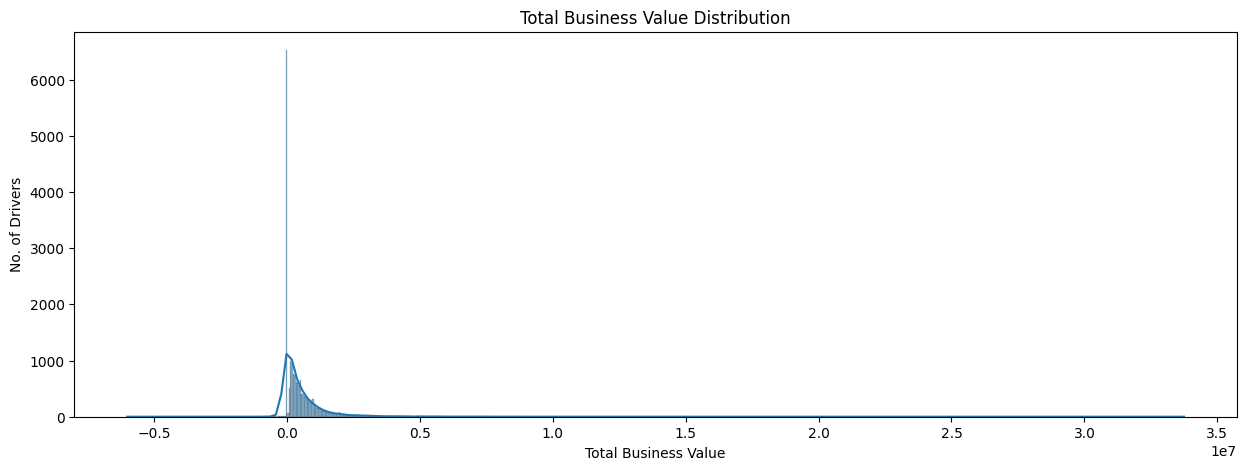

In [ ]:
# Combined Plot (HISTOGRAM + KDE PLOT)
plt.figure(figsize=(15,5))
sns.histplot(df['Total Business Value'], kde=True)
plt.title("Total Business Value Distribution")
plt.ylabel("No. of Drivers")
plt.show()

* The original distribution of Total Business Value is highly right-skewed, with the majority of observations concentrated near lower business values and a long upper tail extending toward extremely high values.

* A relatively small number of drivers contribute disproportionately large business values, causing the histogram to become visually compressed and difficult to interpret.

* This indicates substantial inequality in driver business contribution across the platform.

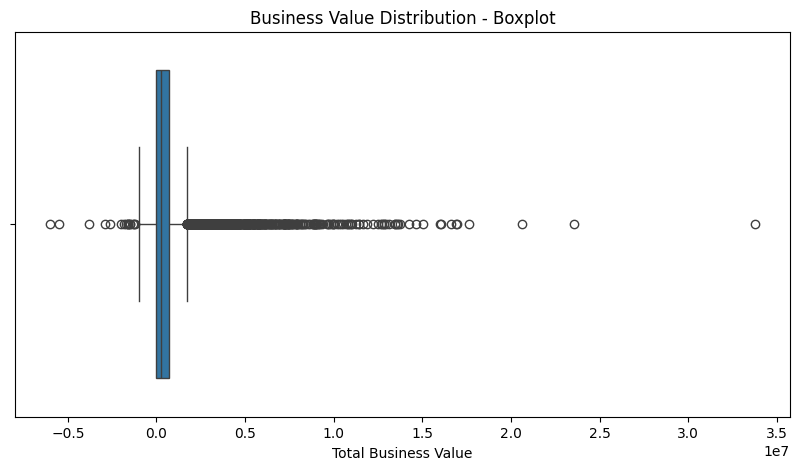

In [ ]:
#boxplot
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Total Business Value'])
plt.title("Business Value Distribution - Boxplot")
plt.show()


* Boxplot analysis confirms the presence of multiple upper-end outliers beyond the upper whisker, further validating the strong positive skewness observed in the histogram.

* However, these extreme values may represent genuine high-performing drivers rather than direct data quality issues, since business platforms often contain a small segment of highly productive contributors.

* Therefore, the outliers were retained for further investigation rather than being immediately removed.

In [ ]:
#IQR
Q1 =df['Total Business Value'].quantile(0.25)
Q3 = df['Total Business Value'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

business_outliers = df[
    (df['Total Business Value'] < lower_bound) |
    (df['Total Business Value'] > upper_bound)
]

print("Number of outliers:", business_outliers.shape[0])
print(f"outlier percentage:- {round((business_outliers.shape[0] / df.shape[0]) * 100,2)}%")


Number of outliers: 1371
outlier percentage:- 7.18%


* IQR-based analysis identified approximately 7.18% of observations as outliers within the Total Business Value distribution.This confirms the presence of substantial positive skewness and heavy-tail behaviour in driver business contribution.

* The results suggest that a relatively limited group of drivers contributes disproportionately higher business value compared to the majority of the  population.

* Since such revenue concentration is common in platform-based businesses, these observations were retained for further analysis rather than being treated as direct anomalies.

#### **Log Transformation**


* Due to the severe positive skewness and visual compression caused by extreme upper-end values, log transformation was explored to improve distribution interpretability.

* Since logarithmic transformation cannot be applied directly to negative or zero values, only positive business value observations were considered for transformation analysis.

In [ ]:
positive_df = df[df['Total Business Value'] > 0]

* Logarithmic transformation is applied using np.log1p() to reduce the impact of extreme values and address positive skewness in the distribution.

* The log1p() function was preferred over the standard logarithm because it safely handles zero-valued observations by computing log(1+x), thereby avoiding undefined values while preserving the benefits of logarithmic scaling.

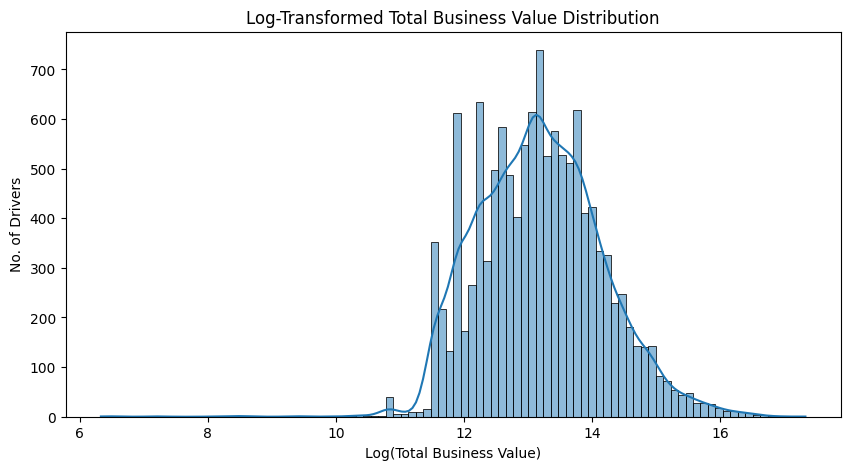

In [ ]:
#log transformation
plt.figure(figsize=(10,5))
sns.histplot(
    np.log1p(positive_df['Total Business Value']),
    kde=True
)

plt.title("Log-Transformed Total Business Value Distribution")
plt.xlabel("Log(Total Business Value)")
plt.ylabel("No. of Drivers")
plt.show()

* After applying logarithmic transformation (log1p), the distribution became significantly more balanced and visually interpretable.

* The transformation successfully compressed the long upper tail and reduced the dominance of extreme observations while preserving the overall data pattern.

* The transformed distribution now appears approximately near-normal with only mild residual skewness, making it more suitable for analytical interpretation and potential machine learning applications.

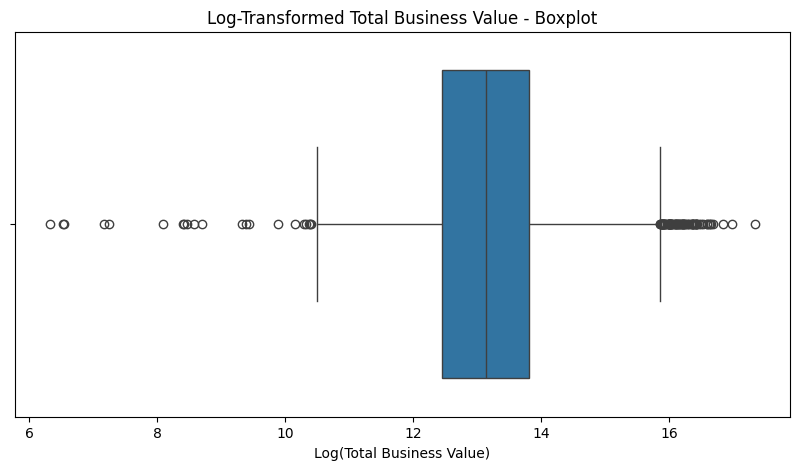

In [ ]:
#boxplot
plt.figure(figsize=(10,5))
sns.boxplot(
    x=np.log1p(positive_df['Total Business Value'])
)

plt.title("Log-Transformed Total Business Value - Boxplot")
plt.xlabel("Log(Total Business Value)")

plt.show()


* The log-transformed boxplot shows a substantial reduction in visible outlier dominance compared to the original scale.

* Although some variability still exists, the transformation stabilised the distribution spread and improved the overall balance of the data without removing meaningful business observations.

In [ ]:
#IQR
Q1 = positive_df['Total Business Value'].quantile(0.25)
Q3 = positive_df['Total Business Value'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

business_outliers = positive_df[
    (positive_df['Total Business Value'] < lower_bound) |
    (positive_df['Total Business Value'] > upper_bound)
]

print("Number of outliers:", business_outliers.shape[0])
print(f"outlier percentage:- {round((business_outliers.shape[0] / df.shape[0]) * 100,2)}%")


Number of outliers: 977
outlier percentage:- 5.11%


* After applying logarithmic transformation, the proportion of detected outliers reduced from approximately 7.18% to 5.11%.

* This indicates that the transformation successfully compressed the influence of extreme upper-end observations and stabilised the overall distribution spread.

* Although some outlier presence still remains, the transformed distribution is significantly more balanced and suitable for analytical interpretation compared to the original scale.

* The remaining variability likely reflects genuine differences in driver business performance rather than purely anomalous observations.

### **E. Quarterly Rating**



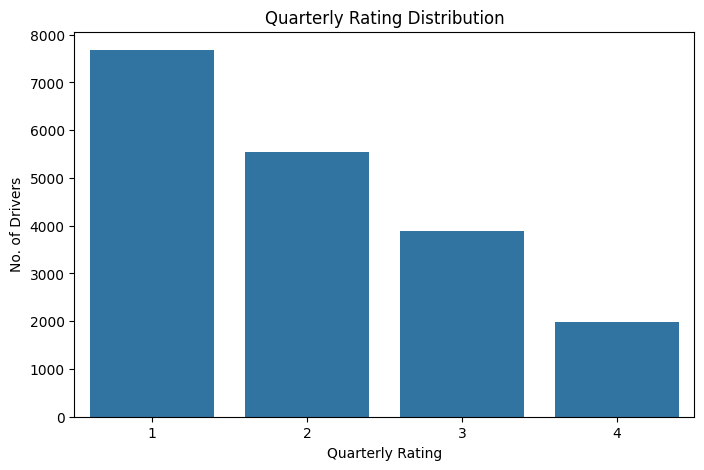

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Quarterly Rating',
    data=df
)

plt.title("Quarterly Rating Distribution")
plt.xlabel("Quarterly Rating")
plt.ylabel("No. of Drivers")

plt.show()

In [ ]:
round(df['Quarterly Rating'].value_counts(normalize=True) * 100,2)

,proportion
Quarterly Rating,
1,40.20
2,29.07
3,20.39
4,10.35


* The Quarterly Rating distribution is heavily concentrated toward lower rating categories, with approximately 40% of drivers receiving a rating of 1 and only around 10% receiving the highest observed rating of 4.

* This suggests that high-performing drivers represent a relatively small segment of the overall driver population.

* Since driver ratings can significantly influence customer satisfaction, ride experience, and platform retention, the dominance of lower-rated drivers may indicate potential operational or service-quality challenges within the platform ecosystem.

* Possible contributing factors may include inconsistent driver performance, limited customer experience standardisation, training gaps, or incentive structures that do not sufficiently encourage service excellence.

* Further analysis is required to determine whether lower driver ratings are associated with increased churn, reduced business value, or weaker customer engagement outcomes.




### **F. Education Level**

In [ ]:
education_map = {
    0: '10th Pass',
    1: '12th Pass',
    2: 'Graduate'
}

df['Education_Label'] = df['Education_Level'].map(education_map)

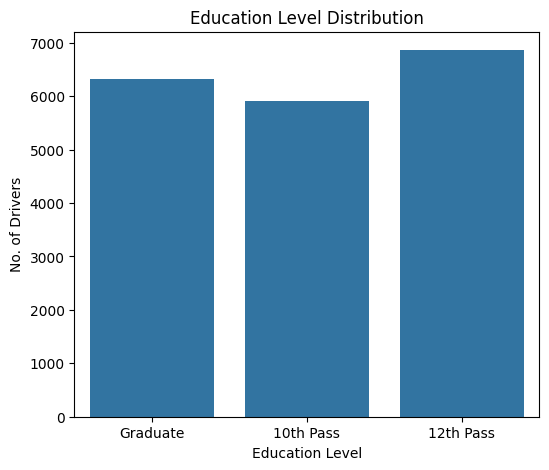

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='Education_Label',
    data=df
)

plt.title("Education Level Distribution")
plt.xlabel("Education Level")
plt.ylabel("No. of Drivers")

plt.show()

In [ ]:
round(df['Education_Label'].value_counts(normalize=True) * 100,2)

,proportion
Education_Label,
12th Pass,35.93
Graduate,33.12
10th Pass,30.95


* The Education_Level distribution appears relatively balanced across all categories, indicating that the driver workforce consists of a fairly diverse educational background.

* Drivers with 12th-pass education form the largest segment of the dataset, followed closely by graduates, while 10th-pass drivers represent a slightly smaller proportion.

* Since the variation across categories is not substantial, education level alone may not strongly differentiate the driver population. However, further analysis is required to determine whether educational background has any relationship with driver churn, performance, or business contribution.

### **G. Driver Distribution by City**

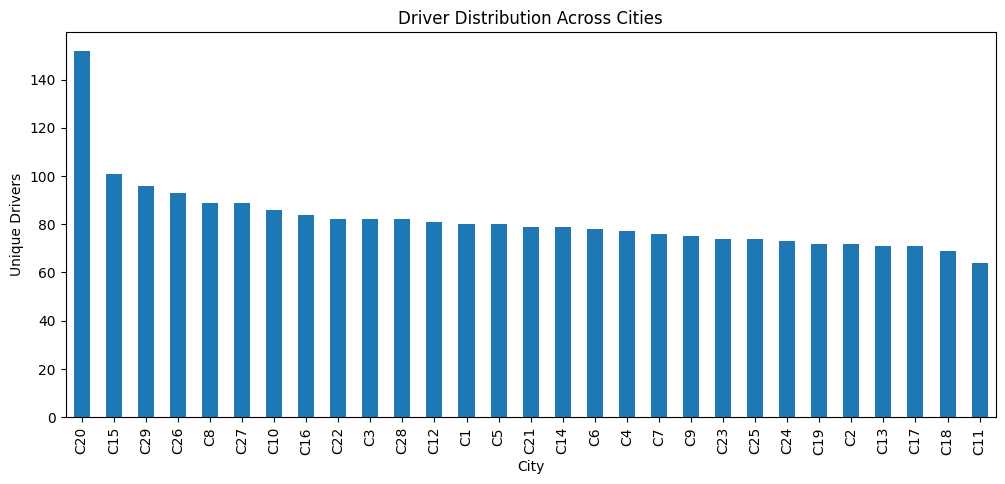

In [ ]:
city_dist = (
    df.groupby('City')['Driver_ID']
      .nunique()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))
city_dist.plot(kind='bar')
plt.title('Driver Distribution Across Cities')
plt.ylabel('Unique Drivers')
plt.show()

* The driver population is distributed across 29 cities, with noticeable variation in the number of drivers per city. City C20 has the highest concentration of drivers, followed by C15, C29, and C26, while cities such as C11, C18, and C17 have comparatively fewer drivers.

* However, the distribution is not extremely skewed, as most cities contain between 70 and 100 drivers. This suggests that the dataset provides reasonable representation across locations and supports further investigation into whether geographical differences influence driver churn behaviour.

## **2.2 Exploratory Relationship Analysis**

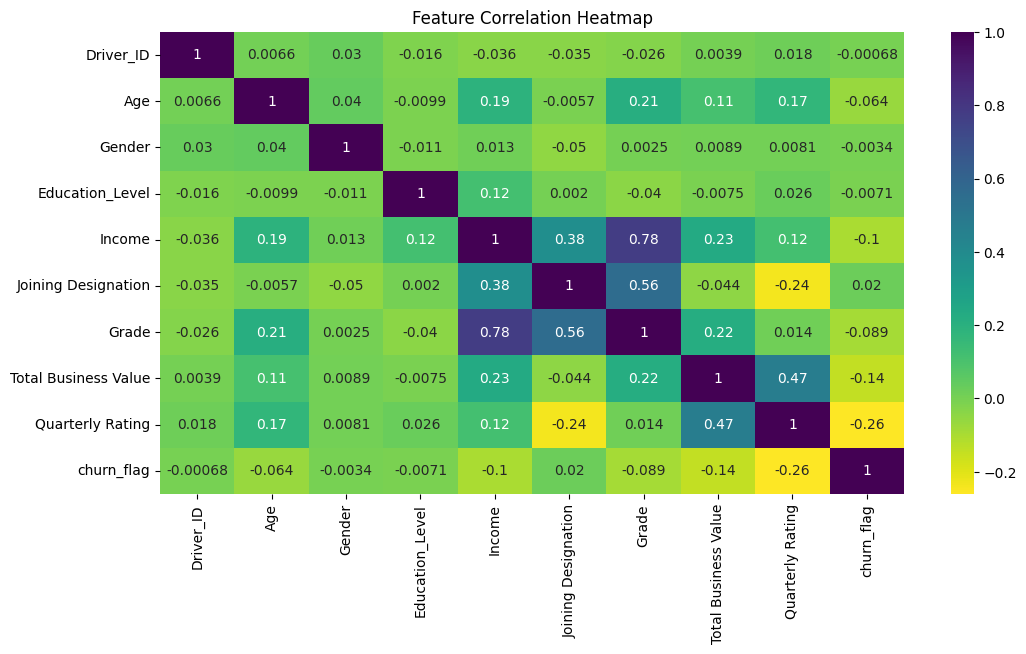

In [ ]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='viridis_r'
)

plt.title("Feature Correlation Heatmap")

plt.show()

* Correlation analysis reveals that Quarterly Rating, Total Business Value, and Income show the strongest negative relationships with churn_flag among the numerical variables.

* In particular, Quarterly Rating demonstrates the highest negative correlation with churn (-0.26), suggesting that better-performing drivers are relatively less likely to leave the platform.

* Total Business Value and Income also exhibit negative relationships with churn, indicating that financially productive and higher-earning drivers tend to show stronger retention behaviour.

* A notable operational relationship is observed between Quarterly Rating and Total Business Value (0.47), suggesting that higher-rated drivers may contribute greater business value to the platform.

* Additionally, Grade shows a strong positive correlation with Income (0.78) and moderate correlation with Total Business Value, indicating that career progression and driver grade may indirectly influence retention through increased earning potential and business contribution.

* Variables such as Education_Level and Age exhibit relatively weak direct relationships with churn, suggesting that demographic characteristics alone may not strongly drive driver attrition.

* Overall, the heatmap provides an initial directional understanding of feature relationships. However, correlation analysis alone does not imply causation, and further bivariate analysis is required to investigate these relationships more deeply.

## **2.3 Targeted Bivariate Analysis**

### **A. Quarterly Rating vs Churn**

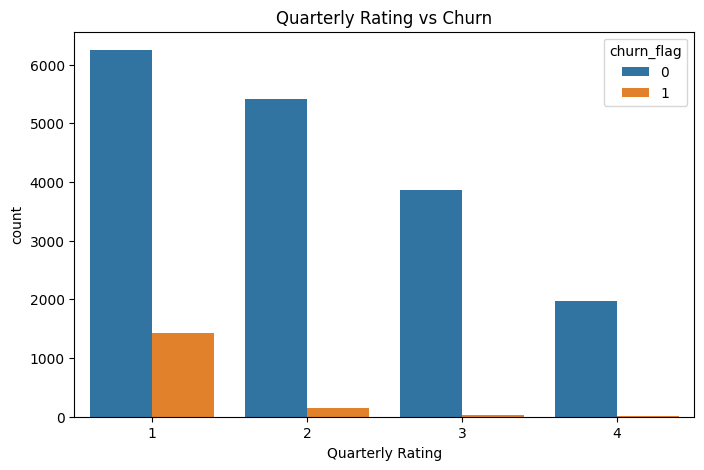

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Quarterly Rating',
    hue='churn_flag',
    data=df
)

plt.title("Quarterly Rating vs Churn")

plt.show()

In [ ]:
pd.crosstab(
    df['Quarterly Rating'],
    df['churn_flag'],
    normalize='index'
) * 100

churn_flag,0,1
Quarterly Rating,,
1,81.351739,18.648261
2,97.370791,2.629209
3,99.281130,0.718870
4,99.494183,0.505817


* Drivers with lower quarterly ratings exhibit substantially higher churn rates compared to higher-rated drivers.

* Nearly 18.6% of drivers with a rating of 1 have churned, whereas churn rates for drivers rated 3 and 4 remain below 1%.

* This suggests that driver performance may play a significant role in retention behaviour, where highly rated and better-performing drivers are considerably more likely to remain active on the platform.

### **B. Income vs Churn**




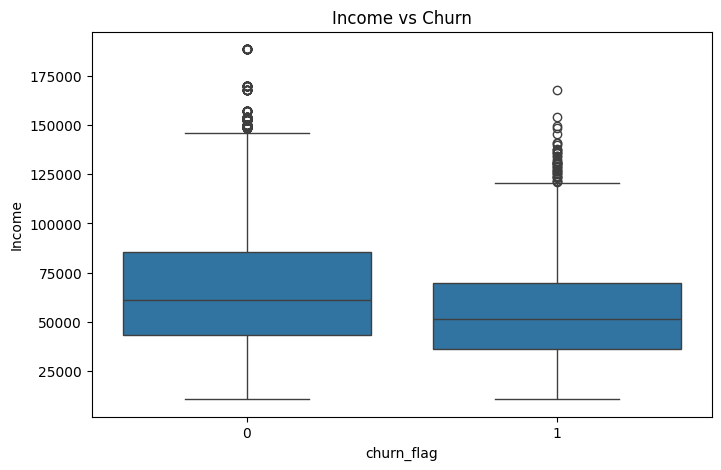

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn_flag',
    y='Income',
    data=df
)

plt.title("Income vs Churn")

plt.show()

* Drivers with lower income levels tend to exhibit relatively higher churn behaviour compared to higher-earning drivers.

* The median income of active drivers is noticeably higher than that of churned drivers, suggesting that stronger earning potential may positively influence driver retention.

* This indicates that financial incentives and income stability may play an important role in reducing driver churn.

### **C. Total Business Value vs Churn**

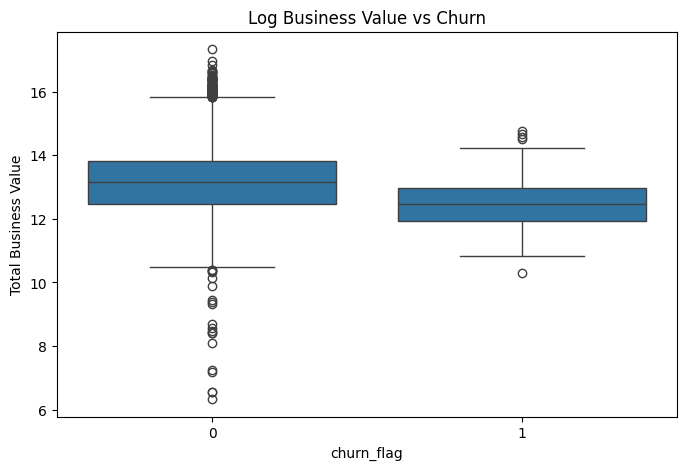

In [ ]:
positive_df = df[df['Total Business Value'] > 0]

plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn_flag',
    y=np.log1p(positive_df['Total Business Value']),
    data=positive_df
)

plt.title("Log Business Value vs Churn")

plt.show()

* Active drivers generally demonstrate higher business value contribution compared to churned drivers.

* The median business value of active drivers is noticeably higher, suggesting that drivers with stronger platform engagement and revenue contribution are relatively less likely to leave the platform.

* Additionally, the active driver segment includes several high-value contributors, indicating that top-performing drivers tend to remain retained within the ecosystem.

* Overall, the relationship suggests that operational productivity and business contribution may play an important role in driver retention behaviour.

### **D. Grade vs Churn**

Text(0, 0.5, 'No. of Drivers')

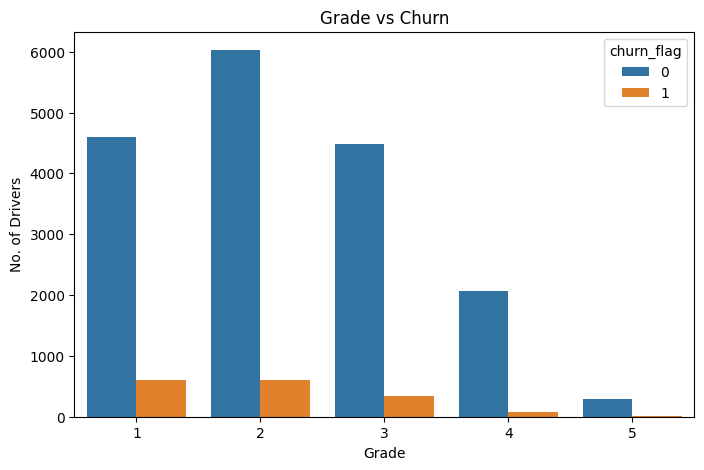

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='Grade',
    hue='churn_flag',
    data=df
)
plt.title("Grade vs Churn")
plt.ylabel("No. of Drivers")

In [ ]:
round(
    pd.crosstab(
        df['Grade'],
        df['churn_flag'],
        normalize='index'
    ) * 100,
    2
)

churn_flag,0,1
Grade,,
1,88.54,11.46
2,90.95,9.05
3,93.02,6.98
4,96.74,3.26
5,95.74,4.26


* Drivers belonging to higher grades generally exhibit lower churn rates compared to lower-grade drivers.

* Churn proportion decreases progressively from Grade 1 to Grade 4, indicating that drivers with stronger career progression or higher operational standing may be more likely to remain active on the platform.

* Since grade also shows strong positive relationships with income and business value, the results suggest that earning potential and professional growth may indirectly contribute to improved driver retention.

### **E. Age vs Churn**

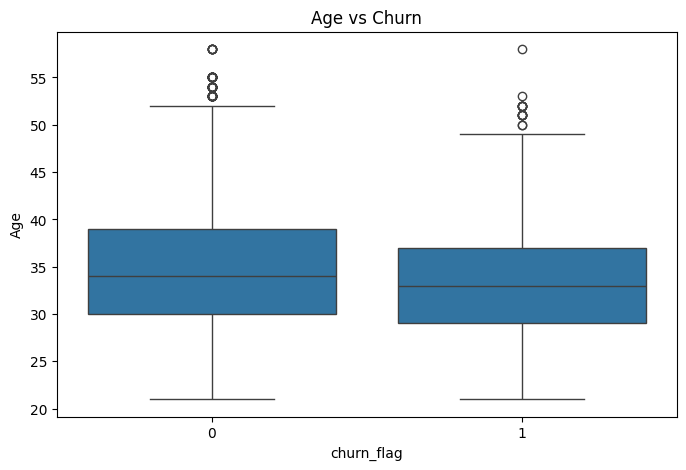

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn_flag',
    y='Age',
    data=df
)

plt.title("Age vs Churn")

plt.show()

* Age does not appear to exhibit a strong relationship with driver churn compared to operational and performance-related variables such as income, quarterly rating, and business value.

* However, the churned driver group shows a slightly lower median age, suggesting that younger drivers may demonstrate marginally higher churning tendencies compared to older drivers.

* Since the overall distribution overlap between churned and active drivers remains substantial, age alone is unlikely to serve as a strong standalone predictor of churn behaviour.

### **F. City vs Churn**

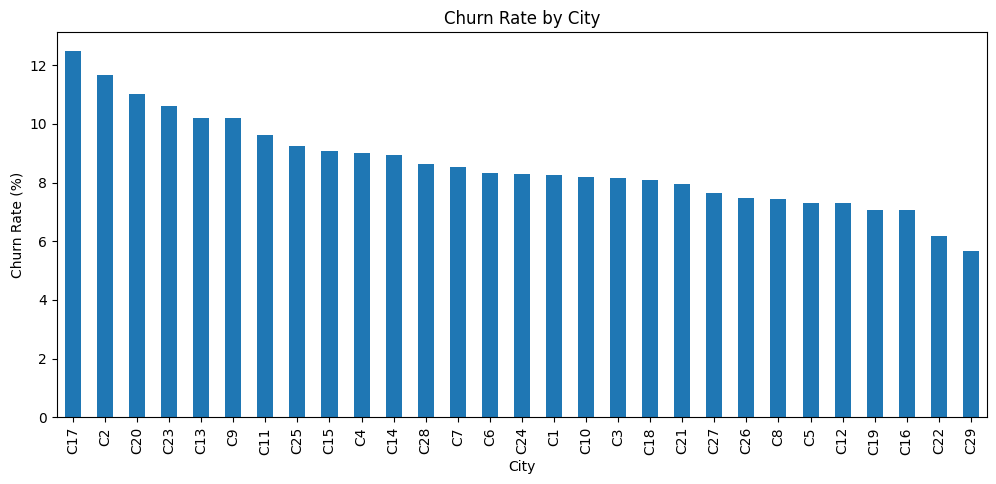

In [ ]:
city_churn = (
    df.groupby('City')['churn_flag']
             .mean()
             .sort_values(ascending=False)
             * 100
)

plt.figure(figsize=(12,5))
city_churn.plot(kind='bar')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by City')
plt.show()

* Churn rates vary considerably across cities, suggesting that geographical factors may influence driver retention. Differences in demand patterns, competition, incentives, traffic conditions, and local operating environments could contribute to these variations.

# **3. Temporal Analysis**

## **A. Drivers Joining & Leaving Trend**



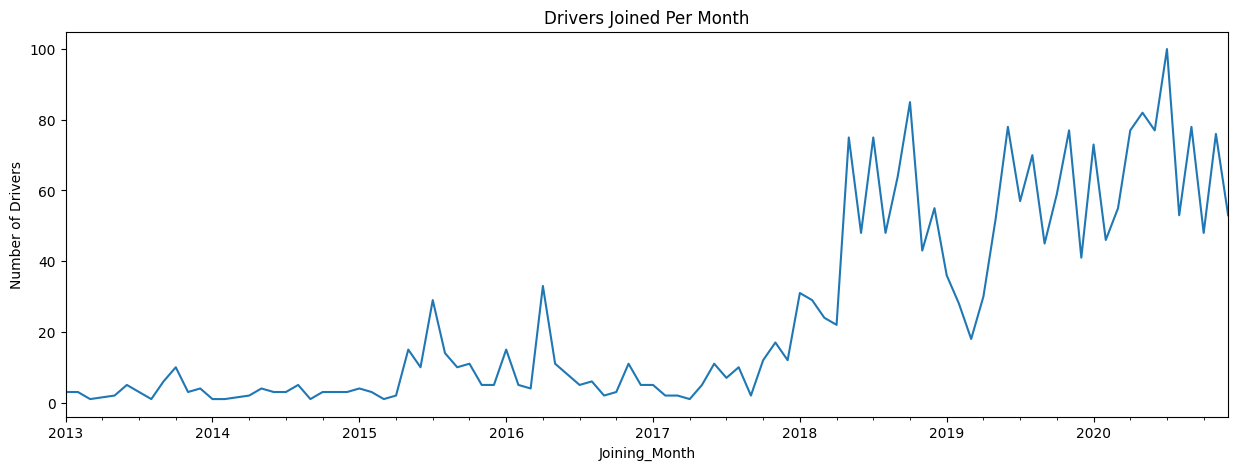

In [ ]:
#creating join month column
df['Joining_Month'] = df['Dateofjoining'].dt.to_period('M')
#joining trend
joining_trend = (
    df.groupby('Joining_Month')['Driver_ID']
    .nunique()
)

joining_trend.plot(figsize=(15,5))

plt.title("Drivers Joined Per Month")
plt.ylabel("Number of Drivers")

plt.show()

* The driver onboarding trend shows a noticeable increase beginning around 2018, indicating substantial workforce expansion during later reporting periods.

* The increasing number of drivers joining the platform may reflect business growth, market expansion, or operational scaling initiatives undertaken during this period.

* However, onboarding activity also demonstrates significant month-to-month fluctuations, suggesting possible sensitivity to changing market and operational conditions.

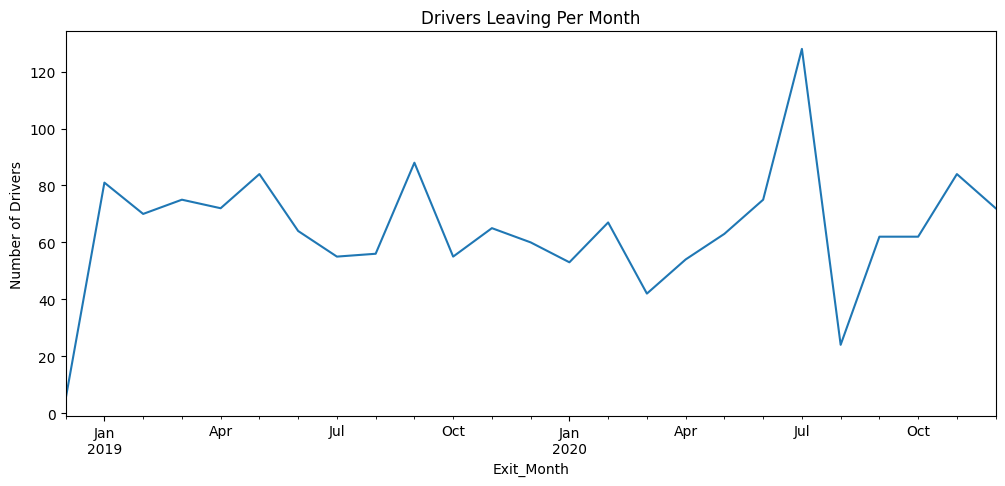

In [ ]:
#using only churned drived
left_drivers = df[df['LastWorkingDate'].notna()].copy()
#creating exit month
left_drivers['Exit_Month'] = (
    left_drivers['LastWorkingDate']
    .dt.to_period('M')
)

#exit trend
exit_trend = (
    left_drivers.groupby('Exit_Month')['Driver_ID']
    .nunique()
)

exit_trend.plot(figsize=(12,5))

plt.title("Drivers Leaving Per Month")
plt.ylabel("Number of Drivers")

plt.show()

* Driver exit trends remain relatively stable across most reporting periods, although a significant spike in driver attrition is observed during mid-2020.

* The sharp rise in driver exits during mid-2020 temporally aligns with the COVID-19 pandemic period, during which the mobility and ride-hailing industry experienced significant operational disruption globally.

* External reports and industry news during this period highlighted challenges such as lockdown restrictions, reduced passenger demand, financial pressure on drivers, and workforce instability, which may have contributed to increased driver attrition trends observed in the dataset.

* Following this spike, driver exits gradually stabilise, indicating possible recovery in platform operations and workforce participation levels.

## **B. Average Driver Tenure**

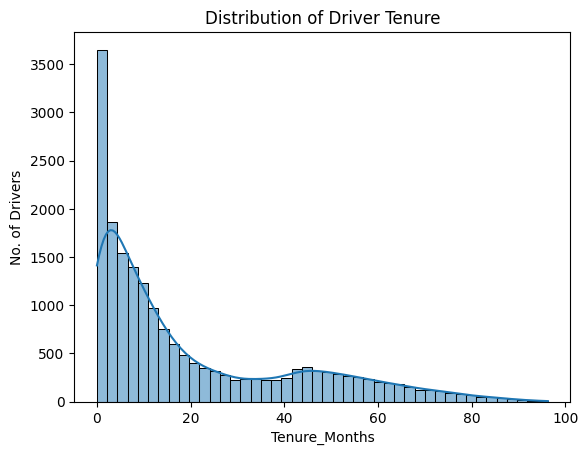


Average Driver Tenure:- 20.17 Months


In [ ]:
# creating end date
tenure_df = df.copy()

tenure_df['End_Date'] = np.where(
    tenure_df['LastWorkingDate'].notna(),
    tenure_df['LastWorkingDate'],
    tenure_df['MMM-YY']
)

# tenure calculation
tenure_df['Tenure_Days'] = (
    pd.to_datetime(tenure_df['End_Date']) -
    tenure_df['Dateofjoining']
).dt.days

# clipping the negative records
tenure_df['Tenure_Days'] = (tenure_df['Tenure_Days'].clip(lower=0))
# convert to months
tenure_df['Tenure_Months'] = (
    tenure_df['Tenure_Days'] / 30
)
#plotting it
sns.histplot(
    tenure_df['Tenure_Months'],
    kde=True
)

plt.title("Distribution of Driver Tenure")
plt.ylabel('No. of Drivers')
plt.show()


#average tenure
print(f"\nAverage Driver Tenure:- {round(tenure_df['Tenure_Months'].mean(),2)} Months")


* Driver tenure shows a strongly right-skewed distribution, with most drivers remaining active for shorter durations and relatively fewer drivers demonstrating long-term retention.

* The average tenure of approximately 20.17 months indicates moderate driver retention within the platform, after addressing date inconsistencies in the source data

# **4. Transition from Exploratory Analysis to Feature Engineering**

In [ ]:
df['Driver_ID'].value_counts().describe()

,count
count,2381.00000
mean,8.02352
std,6.78359
min,1.00000
25%,3.00000
50%,5.00000
75%,10.00000
max,24.00000


The large difference between the mean (8 records) and maximum (24 records) indicates that some drivers remained active in the platform considerably longer than others. This variation further supports the need for driver-level aggregation before model development.

**Why Aggregation is Necessary**

* The exploratory and temporal analyses were conducted on the original monthly reporting dataset, where a single driver could appear across multiple reporting periods. This structure was valuable for understanding overall business trends, driver performance patterns, and temporal behaviour over time.

* However, the business objective of the project is to predict driver churn at the individual driver level, where the target variable represents whether a driver ultimately churned or remained active.

* An analysis of driver record frequency showed that drivers appeared multiple times in the dataset, with an average of approximately 8 monthly records per driver, a median of 5 records, and a maximum of 24 records. This confirms that the raw dataset contains repeated observations of the same driver across different months.

* Using the monthly dataset directly for modelling would result in duplicate driver representations and could bias the model by giving disproportionate influence to drivers with more reporting records.

* Therefore, the dataset was aggregated to create a single consolidated record for each driver. Feature engineering was subsequently performed to capture each driver's latest status, performance trajectory, tenure, and business contribution, resulting in a driver-level modelling dataset containing 2,381 unique drivers.


# **5. Feature Engineering**

* The original dataset contains monthly observations for each driver. To build a churn prediction model, the data must be transformed into a driver-level dataset where each driver is represented by a single consolidated record.

* In addition to aggregating existing variables, new behavioural features are created to capture driver experience, performance trends, earnings progression, and career growth.

## **Creating Driver-Level Dataset**

### **Driver Level Aggregation**

Since multiple records exist for each driver across different reporting months, driver-level aggregation is performed to create a consolidated behavioural profile for modelling purposes.

In [ ]:
#sorting the dataframe
df = df.sort_values(
    by=['Driver_ID', 'MMM-YY']
)
#creating driver level agg
driver_df = df.groupby('Driver_ID').agg(

    Age=('Age','last'),
    Gender=('Gender','first'),
    Education_Level=('Education_Level','first'),

    Joining_Designation=('Joining Designation','first'),

    Latest_Grade=('Grade','last'),

    Latest_Rating=('Quarterly Rating','last'),

    Latest_Income=('Income','last'),

    Total_Business_Value=('Total Business Value','sum'),

    churn_flag=('churn_flag','max')

).reset_index()

## **Tenure**

Driver tenure represents the duration of a driver's association with the platform. It is an important retention metric, as longer-tenured drivers are generally expected to exhibit stronger platform engagement and lower churn tendencies.

In [ ]:
#sorting the values
df = df.sort_values(
    ['Driver_ID','MMM-YY']
)
#tenure feature
driver_tenure = (
    df.groupby('Driver_ID')
      .agg(
          Dateofjoining=('Dateofjoining', 'first'),
          LastWorkingDate=('LastWorkingDate', 'last'),
          Latest_Report_Date=('MMM-YY', 'last')
      )
      .reset_index()
)
#create end date
driver_tenure['End_Date'] = (
    driver_tenure['LastWorkingDate']
    .fillna(driver_tenure['Latest_Report_Date'])
)

#datetime conversion
driver_tenure['End_Date'] = pd.to_datetime(
    driver_tenure['End_Date']
)
#tenure calculation
driver_tenure['Tenure_Months'] = (
    (
        driver_tenure['End_Date']
        -
        driver_tenure['Dateofjoining']
    ).dt.days
) / 30

In [ ]:
#negative tenure values
driver_tenure[
    driver_tenure['Tenure_Months'] < 0
]

,Driver_ID,Dateofjoining,LastWorkingDate,Latest_Report_Date,End_Date,Tenure_Months
3,5,2019-09-01,2019-07-03,2019-03-01,2019-07-03,-2.000000
12,18,2019-09-01,2019-04-30,2019-05-01,2019-04-30,-4.133333
23,35,2020-07-03,2020-05-05,2020-05-01,2020-05-05,-1.966667
45,59,2019-06-01,2019-03-28,2019-03-01,2019-03-28,-2.166667
66,82,2020-11-04,2020-07-29,2020-08-01,2020-07-29,-3.266667
...,...,...,...,...,...,...
2301,2698,2020-03-17,2020-01-05,2020-05-01,2020-01-05,-2.400000
2304,2701,2019-07-18,2019-05-10,2019-10-01,2019-05-10,-2.300000
2316,2713,2019-06-30,2019-04-10,2019-10-01,2019-04-10,-2.700000
2335,2733,2020-12-09,2020-11-28,2020-12-01,2020-11-28,-0.366667


During tenure feature engineering, a small subset of drivers exhibited negative tenure values due to inconsistencies between joining dates and reporting/exit dates in the source data. Since negative tenure is not meaningful from a business perspective, these values were capped at zero to preserve driver records while maintaining logical consistency.

In [ ]:
# DATA QUALITY FIX
driver_tenure['Tenure_Months'] = (
    driver_tenure['Tenure_Months']
    .clip(lower=0)
)

# verify
print(
    "Negative tenure records:",
    (driver_tenure['Tenure_Months'] < 0).sum()
)

# keep only required columns
driver_tenure = driver_tenure[
    ['Driver_ID', 'Tenure_Months']
]

Negative tenure records: 0


In [ ]:
driver_tenure[
    driver_tenure['Tenure_Months'] < 0
].count()

,0
Driver_ID,0
Tenure_Months,0


In [ ]:
#adding it to the driver level dataset
driver_df =driver_df.merge(
    driver_tenure,
    on='Driver_ID',
    how='left'
)

In [ ]:
round(
    driver_df['churn_flag']
    .value_counts(normalize=True) * 100,
    2
)

,proportion
churn_flag,
1,67.87
0,32.13


In [ ]:
df[df['LastWorkingDate'].notna()]['Driver_ID'].nunique()

1616

## **Income Growth**

Current income alone may not fully explain driver behaviour. Therefore, income growth is calculated to capture changes in earning potential over time, which may influence retention decisions.

In [ ]:
#first_income
first_income = (
    df.groupby('Driver_ID')['Income']
    .first()
)
#latest_income
latest_income = (
    df.groupby('Driver_ID')['Income']
    .last()
)
#income_growth
income_growth = (
    latest_income - first_income
).reset_index()

income_growth.columns = [
    'Driver_ID',
    'Income_Growth'
]

In [ ]:
#adding it to the driver level dataset
driver_df = driver_df.merge(
    income_growth,
    on='Driver_ID'
)

## **Rating Growth**

Rating growth measures changes in driver performance over time. Improving ratings may indicate increased engagement and service quality, whereas declining ratings may signal disengagement or higher churn risk.

In [ ]:
first_rating = (
    df.groupby('Driver_ID')['Quarterly Rating']
    .first()
)

latest_rating = (
    df.groupby('Driver_ID')['Quarterly Rating']
    .last()
)

rating_growth = (
    latest_rating - first_rating
).reset_index()

rating_growth.columns = [
    'Driver_ID',
    'Rating_Growth'
]

In [ ]:
#adding it to the driver datatset
driver_df = driver_df.merge(
    rating_growth,
    on='Driver_ID'
)

## **Grade Progression**

Before creating the Grade Progression feature, it is important to verify whether Joining Designation and Grade represent comparable hierarchical levels. If both variables follow a common progression structure, the difference between them can be used as a meaningful measure of career advancement.

In [ ]:
pd.crosstab(
    df['Joining Designation'],
    df['Grade']
)

Grade,1,2,3,4,5
Joining Designation,,,,,
1,5202,2441,1405,721,62
2,0,4186,698,972,99
3,0,0,2723,117,7
4,0,0,0,334,7
5,0,0,0,0,130


In [ ]:
df[['Joining Designation','Grade']].describe()

,Joining Designation,Grade
count,19104.000000,19104.000000
mean,1.690536,2.252670
std,0.836984,1.026512
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,2.000000
75%,2.000000,3.000000
max,5.000000,5.000000


* The crosstab indicates that a driver's current grade is never lower than their joining designation, suggesting a hierarchical progression structure within the organisation.

* Since many drivers advance to higher grades over time, Grade contains additional information beyond Joining Designation and can be used to derive a meaningful Grade_Progression feature representing career growth.
* Grade progression captures career advancement within the platform. Drivers who experience professional growth may be more likely to remain active compared to those with limited progression opportunities.

In [ ]:
grade_progression = (

    df.groupby('Driver_ID')['Grade']
    .last()

    -

    df.groupby('Driver_ID')['Joining Designation']
    .first()

).reset_index()

grade_progression.columns = [
    'Driver_ID',
    'Grade_Progression'
]

In [ ]:
#adding it to the driver level dataset
driver_df = driver_df.merge(
    grade_progression,
    on='Driver_ID'
)

## **Primary City**

In [ ]:
# Primary city for each driver
driver_city = (
    df.groupby('Driver_ID')
      .agg(
          Primary_City=('City', lambda x: x.mode().iloc[0])
      )
      .reset_index()
)
#adding it to the dataset
driver_df = driver_df.merge(
    driver_city,
    on='Driver_ID',
    how='left'
)


City-level analysis revealed meaningful differences in churn behaviour across locations. Therefore, a Primary City feature was created by assigning each driver to the city in which they appeared most frequently during the reporting period. This feature was retained for predictive modelling to capture potential geographical influences on driver churn.

###**View of the Driver-Level Dataset and Created Feautures**

In [ ]:
driver_df.head()

,Driver_ID,Age,Gender,Education_Level,Joining_Designation,Latest_Grade,Latest_Rating,Latest_Income,Total_Business_Value,churn_flag,Tenure_Months,Income_Growth,Rating_Growth,Grade_Progression,Primary_City
0,1,28.0,0.0,2,1,1,2,57387,1715580,1,10.466667,0,0,0,C23
1,2,31.0,0.0,2,2,2,1,67016,0,0,5.766667,0,0,0,C7
2,4,43.0,0.0,2,2,2,1,65603,350000,1,9.666667,0,0,0,C13
3,5,29.0,0.0,0,1,1,1,46368,120360,1,0.000000,0,0,0,C9
4,6,31.0,1.0,1,3,3,2,78728,1265000,0,4.100000,0,1,0,C11


* Since the original dataset contains monthly observations for each driver, driver-level aggregation was performed to create a consolidated behavioural profile for churn prediction.

* Additional features such as tenure, income growth, rating growth, and grade progression were engineered to capture driver performance trends, career progression, and earnings trajectory over time. These features are expected to provide stronger predictive signals than static demographic attributes alone.

# **6. Feature Validation & Final Dataset Review**

In [ ]:
#Shape of the dataset
driver_df.shape

(2381, 15)

In [ ]:
#preview of dataset
driver_df.head()

,Driver_ID,Age,Gender,Education_Level,Joining_Designation,Latest_Grade,Latest_Rating,Latest_Income,Total_Business_Value,churn_flag,Tenure_Months,Income_Growth,Rating_Growth,Grade_Progression,Primary_City
0,1,28.0,0.0,2,1,1,2,57387,1715580,1,10.466667,0,0,0,C23
1,2,31.0,0.0,2,2,2,1,67016,0,0,5.766667,0,0,0,C7
2,4,43.0,0.0,2,2,2,1,65603,350000,1,9.666667,0,0,0,C13
3,5,29.0,0.0,0,1,1,1,46368,120360,1,0.000000,0,0,0,C9
4,6,31.0,1.0,1,3,3,2,78728,1265000,0,4.100000,0,1,0,C11


In [ ]:
#columns and their data types
driver_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2381 entries, 0 to 2380
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Driver_ID             2381 non-null   int64  
 1   Age                   2381 non-null   float64
 2   Gender                2381 non-null   float64
 3   Education_Level       2381 non-null   int64  
 4   Joining_Designation   2381 non-null   int64  
 5   Latest_Grade          2381 non-null   int64  
 6   Latest_Rating         2381 non-null   int64  
 7   Latest_Income         2381 non-null   int64  
 8   Total_Business_Value  2381 non-null   int64  
 9   churn_flag            2381 non-null   int64  
 10  Tenure_Months         2381 non-null   float64
 11  Income_Growth         2381 non-null   int64  
 12  Rating_Growth         2381 non-null   int64  
 13  Grade_Progression     2381 non-null   int64  
 14  Primary_City          2381 non-null   object 
dtypes: float64(3), int64(

In [ ]:
#missing values
driver_df.isna().sum()

,0
Driver_ID,0
Age,0
Gender,0
Education_Level,0
Joining_Designation,0
Latest_Grade,0
Latest_Rating,0
Latest_Income,0
Total_Business_Value,0
churn_flag,0


In [ ]:
#statistical summary
driver_df.describe()

,Driver_ID,Age,Gender,Education_Level,Joining_Designation,Latest_Grade,Latest_Rating,Latest_Income,Total_Business_Value,churn_flag,Tenure_Months,Income_Growth,Rating_Growth,Grade_Progression
count,2381.000000,2381.000000,2381.000000,2381.00000,2381.000000,2381.000000,2381.000000,2381.000000,2.381000e+03,2381.000000,2381.000000,2381.000000,2381.000000,2381.000000
mean,1397.559009,33.662327,0.410332,1.00756,1.820244,2.096598,1.427971,59334.157077,4.586742e+06,0.678706,14.844911,125.096178,-0.058379,0.276354
std,806.161628,5.984100,0.491997,0.81629,0.841433,0.941522,0.809839,28383.666384,9.127115e+06,0.467071,18.879534,968.511766,0.933703,0.682358
min,1.000000,21.000000,0.000000,0.00000,1.000000,1.000000,1.000000,10747.000000,-1.385530e+06,0.000000,0.000000,0.000000,-3.000000,0.000000
25%,695.000000,29.000000,0.000000,0.00000,1.000000,1.000000,1.000000,39104.000000,0.000000e+00,0.000000,3.333333,0.000000,0.000000,0.000000
50%,1400.000000,33.000000,0.000000,1.00000,2.000000,2.000000,1.000000,55315.000000,8.176800e+05,1.000000,7.700000,0.000000,0.000000,0.000000
75%,2100.000000,37.000000,1.000000,2.00000,2.000000,3.000000,2.000000,75986.000000,4.173650e+06,1.000000,16.600000,0.000000,0.000000,0.000000
max,2788.000000,58.000000,1.000000,2.00000,5.000000,5.000000,4.000000,188418.000000,9.533106e+07,1.000000,96.266667,12155.000000,3.000000,4.000000


* The driver-level dataset was validated after feature engineering to ensure completeness and consistency. The final dataset contains 2,381 unique drivers with no missing values or duplicate records.

* Analysis of the engineered features shows that driver tenure is highly right-skewed, with a median tenure of 7.7 months and an average tenure of 14.8 months, indicating that most drivers remain on the platform for a relatively short period while a smaller group stays significantly longer.

* Income growth, rating growth, and grade progression exhibit median values close to zero, suggesting that the majority of drivers experience limited changes in earnings, performance ratings, and organisational grade over time. However, a smaller subset demonstrates notable improvements in these areas.

* Total Business Value remains positively skewed, reflecting the presence of a relatively small group of highly productive drivers who contribute disproportionately to overall business generation.

* Overall, the engineered features successfully capture driver demographics, earnings, performance, career progression, business contribution, and platform engagement, providing a strong foundation for churn prediction modelling.

## **Target Variable Validation**

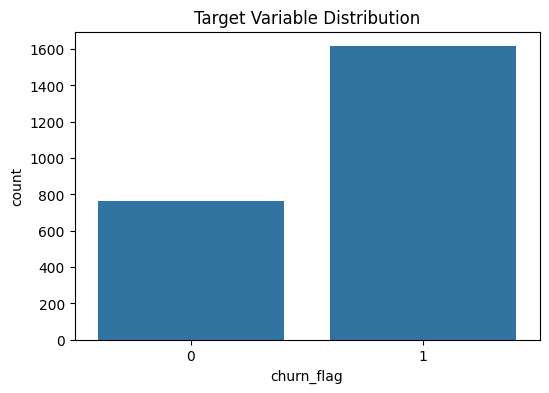

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='churn_flag',
    data=driver_df
)

plt.title('Target Variable Distribution')
plt.show()


In [ ]:
#percentage
round(
    driver_df['churn_flag']
    .value_counts(normalize=True) * 100,
    2)

,proportion
churn_flag,
1,67.87
0,32.13


The target variable exhibits moderate class imbalance, with approximately 67.9% of drivers classified as churned and 32.1% remaining active. This imbalance will be considered during model development through appropriate evaluation metrics and class weighting techniques.

# **7. Additional Relationship Analysis**

## **A. Age vs Latest Income**

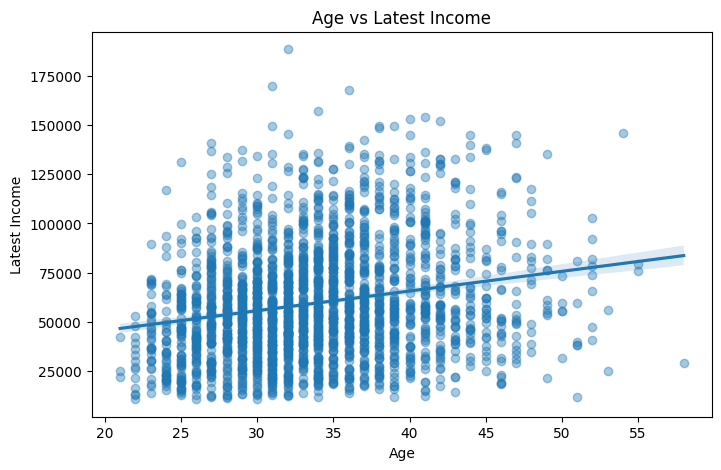

,Age,Latest_Income
Age,1.000000,0.210772
Latest_Income,0.210772,1.000000


In [ ]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=driver_df,
    x='Age',
    y='Latest_Income',
    scatter_kws={'alpha':0.4}
)

plt.title('Age vs Latest Income')
plt.xlabel('Age')
plt.ylabel('Latest Income')

plt.show()

# Correlation Value
driver_df[['Age','Latest_Income']].corr()

* A weak positive relationship (r = 0.21) is observed between age and income, indicating that older drivers tend to earn slightly higher incomes.

* However, the large variation in income within each age group suggests that driver earnings are influenced more by performance, business activity, and experience on the platform than by age alone

## **B. Education Level vs Total Business Value**

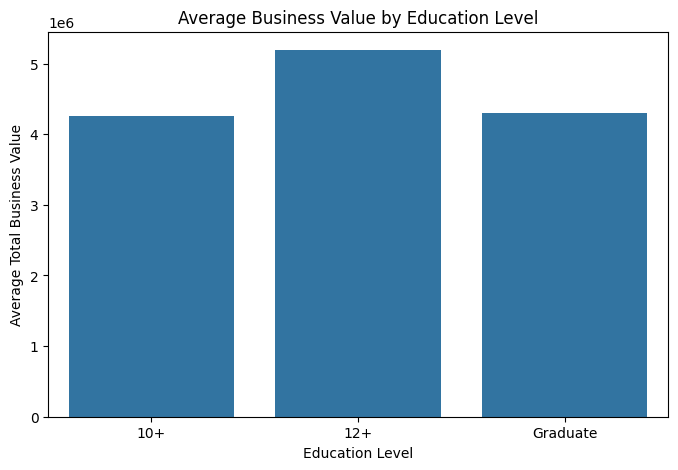

In [ ]:
edu_bv = (
    driver_df.groupby('Education_Level')
             ['Total_Business_Value']
             .mean()
             .reset_index()
)

edu_bv['Education_Level'] = edu_bv[
    'Education_Level'
].map({
    0:'10+',
    1:'12+',
    2:'Graduate'
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=edu_bv,
    x='Education_Level',
    y='Total_Business_Value'
)

plt.title('Average Business Value by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Total Business Value')

plt.show()

* Average business value varied across education levels, with drivers having 12+ education generating the highest average business value.
 * However, the differences across education groups were relatively modest, suggesting that educational qualification is not a major determinant of business performance among drivers.

## **C. Primary City vs Total Business Value**

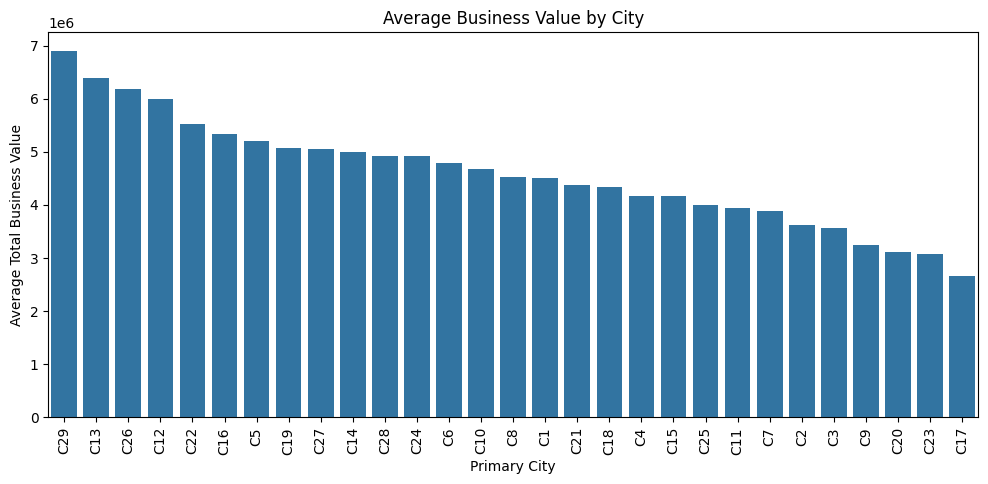

In [ ]:
city_bv = (
    driver_df.groupby('Primary_City')
             ['Total_Business_Value']
             .mean()
             .sort_values(
                 ascending=False
             )
             .reset_index()
)

plt.figure(figsize=(12,5))

sns.barplot(
    data=city_bv,
    x='Primary_City',
    y='Total_Business_Value'
)

plt.xticks(rotation=90)

plt.title('Average Business Value by City')
plt.xlabel('Primary City')
plt.ylabel('Average Total Business Value')

plt.show()

* Average business value differed significantly across cities, indicating the presence of regional variations in demand, customer activity, and market conditions.
* Drivers operating in cities such as C29 and C13 generated considerably higher business value compared to those in lower-performing cities, suggesting that geographical factors may influence driver productivity and revenue generation.

## **D. Quarterly Rating vs Total Business Value**

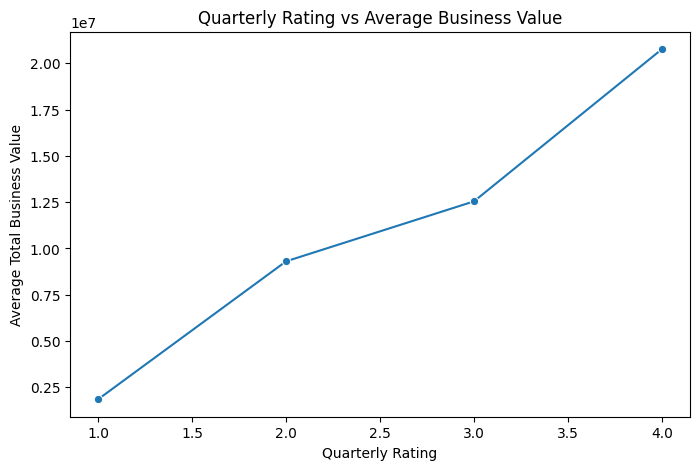

In [ ]:
rating_bv = (
    driver_df.groupby('Latest_Rating')
             ['Total_Business_Value']
             .mean()
             .reset_index()
)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=rating_bv,
    x='Latest_Rating',
    y='Total_Business_Value',
    marker='o'
)

plt.title(
    'Quarterly Rating vs Average Business Value'
)

plt.xlabel('Quarterly Rating')
plt.ylabel('Average Total Business Value')

plt.show()

* A strong positive relationship was observed between quarterly rating and business value.
* Drivers with higher ratings consistently generated greater business value, suggesting that service quality and customer satisfaction are closely linked to revenue generation.
* This highlights the importance of maintaining high service standards to improve both driver performance and business outcomes.

###**Relationship Analysis Summary**

* The relationship analysis revealed that while demographic factors such as age and education exhibited relatively weak associations with driver performance, operational factors such as city and quarterly rating showed stronger relationships with business value.
 * In particular, quarterly rating emerged as a key indicator of driver productivity, reinforcing the importance of performance-related metrics in understanding driver success on the platform.

# **8. Multicollinearity Analysis**

## **Feature Correlation Heatmap**

Correlation analysis is performed to identify relationships among predictor variables and assess potential multicollinearity.


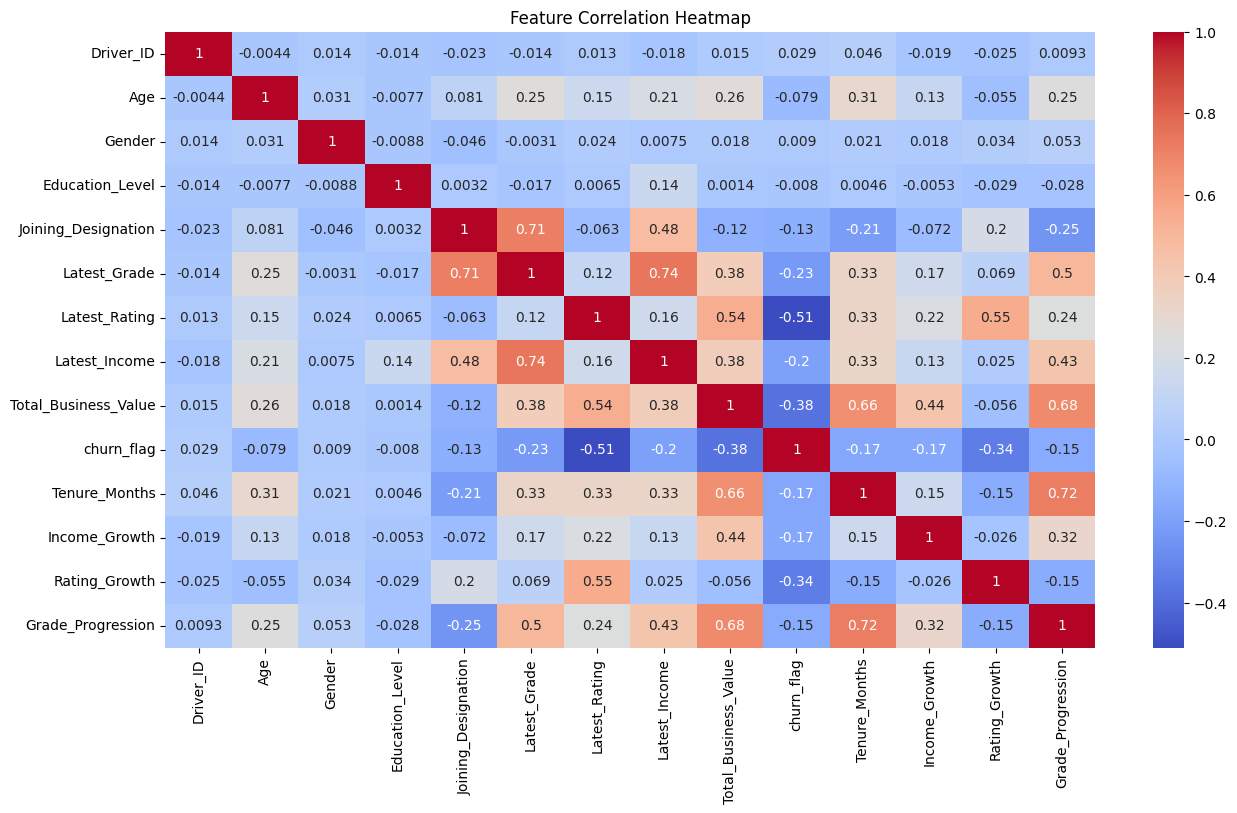

In [ ]:
plt.figure(figsize=(15,8))

sns.heatmap(
    driver_df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

* Driver performance appears to be the strongest indicator of churn. Drivers with higher ratings, greater business generation, and improving ratings are less likely to leave the platform. This suggests that driver engagement and success on the platform are closely linked to retention.

* Demographic characteristics such as age, gender, and education level show very weak relationships with churn, suggesting that behavioural and performance-related factors are more influential than personal attributes.


* Most features exhibit weak to moderate correlations, indicating that they capture distinct aspects of driver behaviour and performance.

* The strongest positive correlations were observed between Latest Grade and Latest Income (0.74), Tenure Months and Grade Progression (0.72), and Joining Designation and Latest Grade (0.71), reflecting expected business relationships.

* No feature pair exceeded the commonly accepted multicollinearity threshold of 0.80, suggesting that all engineered features can be retained for further modelling.

## **VIF Analysis**

In [ ]:
#dropping certain columns
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = driver_df.drop(
    ['Driver_ID','churn_flag','Primary_City'],
    axis=1
)

vif = pd.DataFrame()

vif['Feature'] = X.columns

vif['VIF'] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

vif.sort_values(
    by='VIF',
    ascending=False
)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
3,Joining_Designation,inf
4,Latest_Grade,inf
11,Grade_Progression,inf
0,Age,15.782631
6,Latest_Income,13.009935
5,Latest_Rating,10.632052
8,Tenure_Months,4.276989
7,Total_Business_Value,4.223826
2,Education_Level,2.600311
10,Rating_Growth,1.996972


* The initial VIF analysis revealed infinite VIF values for Joining Designation, Latest Grade, and Grade Progression. Investigation showed that Grade Progression was engineered using Joining Designation and Latest Grade, creating a perfect linear dependency among the three variables.

* To eliminate redundant information and satisfy Logistic Regression assumptions, one of these variables must be removed before model training.

* As a result, Joining Designation is removed from the feature set to eliminate perfect multicollinearity while retaining information on both current driver status (Latest Grade) and career growth (Grade Progression).

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = driver_df.drop(
    [
        'Driver_ID',
        'churn_flag',
        'Primary_City',
        'Joining_Designation'   # remove this
    ],
    axis=1
)

vif = pd.DataFrame()

vif['Feature'] = X.columns

vif['VIF'] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

vif.sort_values(
    by='VIF',
    ascending=False
)

,Feature,VIF
0,Age,15.782631
3,Latest_Grade,15.564026
5,Latest_Income,13.009935
4,Latest_Rating,10.632052
7,Tenure_Months,4.276989
6,Total_Business_Value,4.223826
10,Grade_Progression,3.420766
2,Education_Level,2.600311
9,Rating_Growth,1.996972
1,Gender,1.687233




* After removing Joining Designation, Latest Grade continued to exhibit a high VIF value of 15.56. Correlation analysis showed a strong positive relationship between Latest Grade and Latest Income (0.74), suggesting substantial overlap between these variables.

* To evaluate this redundancy, Latest Grade is removed and the VIF analysis is repeated.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = driver_df.drop(
    [
        'Driver_ID',
        'churn_flag',
        'Primary_City',
        'Joining_Designation',
        'Latest_Grade'
    ],
    axis=1
)

vif = pd.DataFrame()

vif['Feature'] = X.columns

vif['VIF'] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

vif.sort_values(
    by='VIF',
    ascending=False
)

,Feature,VIF
0,Age,12.493928
3,Latest_Rating,10.415493
4,Latest_Income,6.783263
6,Tenure_Months,4.257707
5,Total_Business_Value,4.214884
9,Grade_Progression,3.240284
2,Education_Level,2.565256
8,Rating_Growth,1.923127
1,Gender,1.686433
7,Income_Growth,1.361060


* This resulted in a significant reduction in the VIF of Latest Income from 13.01 to 6.78, confirming that Latest Grade was contributing substantially to multicollinearity while providing limited additional information beyond income and career progression.

* Following the removal of Latest Grade, elevated VIF values persisted for Age (12.49) and Latest Rating (10.42). Correlation analysis indicated that Latest Rating shared moderate relationships with Rating Growth and Total Business Value, both of which were already retained in the feature set.

* To assess the impact of this redundancy, Latest Rating is removed and the VIF analysis is performed again.


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = driver_df.drop(
    [
        'Driver_ID',
        'churn_flag',
        'Primary_City',
        'Joining_Designation',
        'Latest_Grade',
        'Latest_Rating'
    ],
    axis=1
)

vif = pd.DataFrame()

vif['Feature'] = X.columns

vif['VIF'] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

vif.sort_values(
    by='VIF',
    ascending=False
)

,Feature,VIF
0,Age,7.544957
3,Latest_Income,6.780286
5,Tenure_Months,4.184492
4,Total_Business_Value,3.147222
8,Grade_Progression,3.125273
2,Education_Level,2.537825
1,Gender,1.683737
6,Income_Growth,1.361028
7,Rating_Growth,1.051831


 This reduced the VIF of Age from 12.49 to 7.54 and brought all remaining features below the accepted threshold of 10, indicating that multicollinearity had been effectively addressed.


## **Final Multicollinearity Assessment**

* The final VIF analysis confirmed that all remaining predictor variables exhibited VIF values below the commonly accepted threshold of 10.

* The highest VIF values were observed for Age (7.54) and Latest Income (6.78), while all other variables demonstrated low levels of multicollinearity.
* Through a systematic feature selection process, Joining Designation, Latest Grade, and Latest Rating were removed due to redundancy and their contribution to multicollinearity.
* The final feature set retains information related to driver demographics, earnings, tenure, business contribution, income growth, rating growth, and career progression while ensuring improved model stability and interpretability for Logistic Regression modelling.

# **9. Model Preparation**

**Objective**: Prepare the validated driver-level dataset for Logistic Regression modelling by removing redundant features, encoding categorical variables, and defining predictor and target variables.

## **Modelling Dataset Creation**

In [ ]:
model_df = driver_df.copy()

## **Feature Selection**

In [ ]:
#Drop Features Removed Through VIF
model_df = model_df.drop(
    [
        'Joining_Designation',
        'Latest_Grade',
        'Latest_Rating'
    ],
    axis=1
)

In [ ]:
#verification of the created dataset
model_df.columns

Index(['Driver_ID', 'Age', 'Gender', 'Education_Level', 'Latest_Income',
       'Total_Business_Value', 'churn_flag', 'Tenure_Months', 'Income_Growth',
       'Rating_Growth', 'Grade_Progression', 'Primary_City'],
      dtype='object')

## **Primary City Encoding**

In [ ]:
model_df['Primary_City'].nunique()

29

* Primary City was identified as a nominal categorical variable with 29 unique categories.
* Label Encoding was not considered appropriate because the city identifiers do not possess any inherent ordinal relationship, and assigning numerical labels could introduce artificial ordering into the model.
* Although target encoding is often used for high-cardinality categorical variables, the number of city categories in this dataset was relatively small and computationally manageable.
* Therefore, One-Hot Encoding was selected to preserve the independence of each city category while avoiding the risk of introducing unintended relationships or target leakage.

### **One-Hot Encode Primary_City**

In [ ]:
model_df = pd.get_dummies(
    model_df,
    columns=['Primary_City'],
    drop_first=True,
    dtype=int
)

In [ ]:
#validation of the modelling dataset before assigning the variables
print(model_df.shape)

model_df.head()

print(model_df.isna().sum().sum())

model_df.dtypes.value_counts()

(2381, 39)
0


,count
int64,36
float64,3


The dataset passed all validation checks, including missing value assessment, data type verification, and record count consistency. The prepared dataset is therefore ready for train-test splitting, feature scaling, and model development.

## **Defining Features and Target Variable**

Driver_ID was retained throughout data preparation as a unique identifier for validation and traceability purposes. Prior to model training, Driver_ID is excluded from the predictor set as it does not contain predictive information and could introduce noise into the model.

In [ ]:
X = model_df.drop(
    ['Driver_ID','churn_flag'],
    axis=1
)

y = model_df['churn_flag']

In [ ]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts(normalize=True)*100)

X Shape: (2381, 37)
y Shape: (2381,)

Target Distribution:
churn_flag
1    67.870643
0    32.129357
Name: proportion, dtype: float64


The modelling dataset was validated after feature selection, categorical encoding, and multicollinearity treatment. No missing values were present, all features were converted into numerical format, and the original driver count was preserved. The resulting dataset is suitable for machine learning model development and evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True)*100)
print(y_test.value_counts(normalize=True)*100)

(1904, 37)
(477, 37)
churn_flag
1    67.857143
0    32.142857
Name: proportion, dtype: float64
churn_flag
1    67.924528
0    32.075472
Name: proportion, dtype: float64


The dataset was split into training (80%) and testing (20%) subsets using stratified sampling. The churn distribution remained consistent across the original, training, and testing datasets, confirming that the split preserved the target class proportions and reduced sampling bias during model evaluation.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
).describe()

,Age,Gender,Education_Level,Latest_Income,Total_Business_Value,Tenure_Months,Income_Growth,Rating_Growth,Grade_Progression,Primary_City_C10,...,Primary_City_C27,Primary_City_C28,Primary_City_C29,Primary_City_C3,Primary_City_C4,Primary_City_C5,Primary_City_C6,Primary_City_C7,Primary_City_C8,Primary_City_C9
count,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,...,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1.904000e+03
mean,-4.851395e-17,-1.212849e-16,-4.105026e-17,1.287486e-16,-2.239105e-17,3.545250e-17,5.411171e-17,1.959217e-17,-1.865921e-18,-3.591898e-17,...,2.612289e-17,7.417036e-17,-1.026257e-17,-4.851395e-17,1.009930e-16,-4.011730e-17,0.000000,2.239105e-17,7.277092e-17,1.492737e-17
std,1.000263e+00,1.000263e+00,1.000263e+00,1.000263e+00,1.000263e+00,1.000263e+00,1.000263e+00,1.000263e+00,1.000263e+00,1.000263e+00,...,1.000263e+00,1.000263e+00,1.000263e+00,1.000263e+00,1.000263e+00,1.000263e+00,1.000263,1.000263e+00,1.000263e+00,1.000263e+00
min,-2.131151e+00,-8.412035e-01,-1.225549e+00,-1.728634e+00,-6.459215e-01,-7.739702e-01,-1.187657e-01,-3.271714e+00,-4.016587e-01,-1.996720e-01,...,-1.924501e-01,-1.968104e-01,-2.094270e-01,-1.894956e-01,-1.819291e-01,-1.834641e-01,-0.172470,-1.788248e-01,-1.953662e-01,-1.865010e-01
25%,-7.850864e-01,-8.412035e-01,-1.225549e+00,-7.205414e-01,-4.919005e-01,-6.043375e-01,-1.187657e-01,5.119326e-02,-4.016587e-01,-1.996720e-01,...,-1.924501e-01,-1.968104e-01,-2.094270e-01,-1.894956e-01,-1.819291e-01,-1.834641e-01,-0.172470,-1.788248e-01,-1.953662e-01,-1.865010e-01
50%,-1.120542e-01,-8.412035e-01,-6.433330e-04,-1.391297e-01,-4.094691e-01,-3.781607e-01,-1.187657e-01,5.119326e-02,-4.016587e-01,-1.996720e-01,...,-1.924501e-01,-1.968104e-01,-2.094270e-01,-1.894956e-01,-1.819291e-01,-1.834641e-01,-0.172470,-1.788248e-01,-1.953662e-01,-1.865010e-01
75%,5.609780e-01,1.188773e+00,1.224263e+00,5.909051e-01,-4.905828e-02,8.346971e-02,-1.187657e-01,5.119326e-02,-4.016587e-01,-1.996720e-01,...,-1.924501e-01,-1.968104e-01,-2.094270e-01,-1.894956e-01,-1.819291e-01,-1.834641e-01,-0.172470,-1.788248e-01,-1.953662e-01,-1.865010e-01
max,4.094397e+00,1.188773e+00,1.224263e+00,4.617062e+00,1.010548e+01,4.329144e+00,1.282851e+01,3.374101e+00,5.643860e+00,5.008212e+00,...,5.196152e+00,5.081033e+00,4.774935e+00,5.277166e+00,5.496646e+00,5.450658e+00,5.798119,5.592065e+00,5.118594e+00,5.361903e+00


* Feature scaling was performed using Standard Scaler to standardize all predictor variables before model training. Standardization transformed the features to a common scale with a mean close to 0 and a standard deviation close to 1.
* This step was necessary because Logistic Regression is sensitive to differences in feature magnitude, and scaling ensures that all variables contribute proportionately during model optimization.

# **10. Model Development**

* Logistic Regression was selected as the baseline classification model due to its interpretability, computational efficiency, and suitability for binary classification problems.

* Since the target variable exhibited moderate class imbalance (approximately 68% churned drivers and 32% active drivers), the class_weight='balanced' parameter was used to automatically assign higher importance to the minority class during model training.
* This approach helps reduce model bias towards the majority class and improves the identification of churned drivers.

## **Baseline Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

lr.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

* The Logistic Regression model was successfully trained on the prepared dataset.

* Predicted class labels and churn probabilities were subsequently generated for the test dataset to evaluate model performance using multiple classification metrics.

## **Prediction Generation**

In [ ]:
y_pred = lr.predict(X_test_scaled)

y_prob = lr.predict_proba(
    X_test_scaled
)[:,1]

## **Model Evaluation**

### **Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[102  51]
 [ 44 280]]


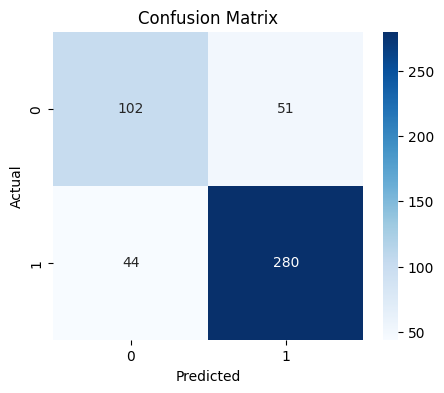

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

* The model correctly classified 382 out of 477 drivers. It successfully identified 280 churned drivers while missing only 44 churn cases.
* From a business perspective, the model is more effective at detecting drivers likely to leave than drivers likely to remain active, which aligns well with the objective of churn prediction.

### **Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.70      0.67      0.68       153
           1       0.85      0.86      0.85       324

    accuracy                           0.80       477
   macro avg       0.77      0.77      0.77       477
weighted avg       0.80      0.80      0.80       477



* The model achieved a recall of 86% for churned drivers, indicating that the majority of drivers who left the platform were successfully identified.    

* Furthermore, a precision of 85% suggests that most drivers predicted as churn risks were indeed churned drivers.
* These results demonstrate strong predictive capability for identifying driver attrition.

### **ROC-AUC Score**

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", round(auc,3))

ROC-AUC: 0.851


The model achieved a ROC-AUC score of 0.851, indicating a strong ability to distinguish between churned and active drivers. This suggests that the selected features provide meaningful predictive information regarding driver attrition.

### **ROC Curve**

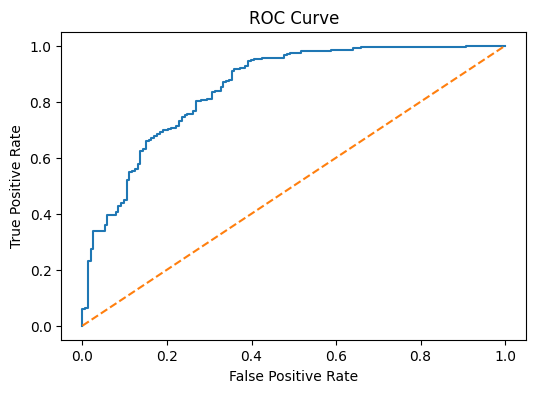

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

The ROC curve remains substantially above the baseline diagonal, further confirming that the model possesses strong discriminatory power when distinguishing between churned and active drivers.

## **Feature Importance Analysis**

### **Model Coefficients**

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

coef_df.sort_values(
    by='Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient
8,Grade_Progression,0.512169
5,Tenure_Months,0.506684
12,Primary_City_C13,0.173786
13,Primary_City_C14,0.143460
27,Primary_City_C27,0.143001
1,Gender,0.141476
20,Primary_City_C20,0.130999
23,Primary_City_C23,0.118374
16,Primary_City_C17,0.113780
25,Primary_City_C25,0.101574


In [ ]:
coef_df.sort_values(
    by='Coefficient'
).head(10)

,Feature,Coefficient
4,Total_Business_Value,-2.097415
7,Rating_Growth,-1.174034
3,Latest_Income,-0.299741
18,Primary_City_C19,-0.077862
6,Income_Growth,-0.035941
29,Primary_City_C29,-0.008362
15,Primary_City_C16,0.002794
35,Primary_City_C8,0.015741
21,Primary_City_C21,0.015879
36,Primary_City_C9,0.020878


### **Feature Importance Plot**

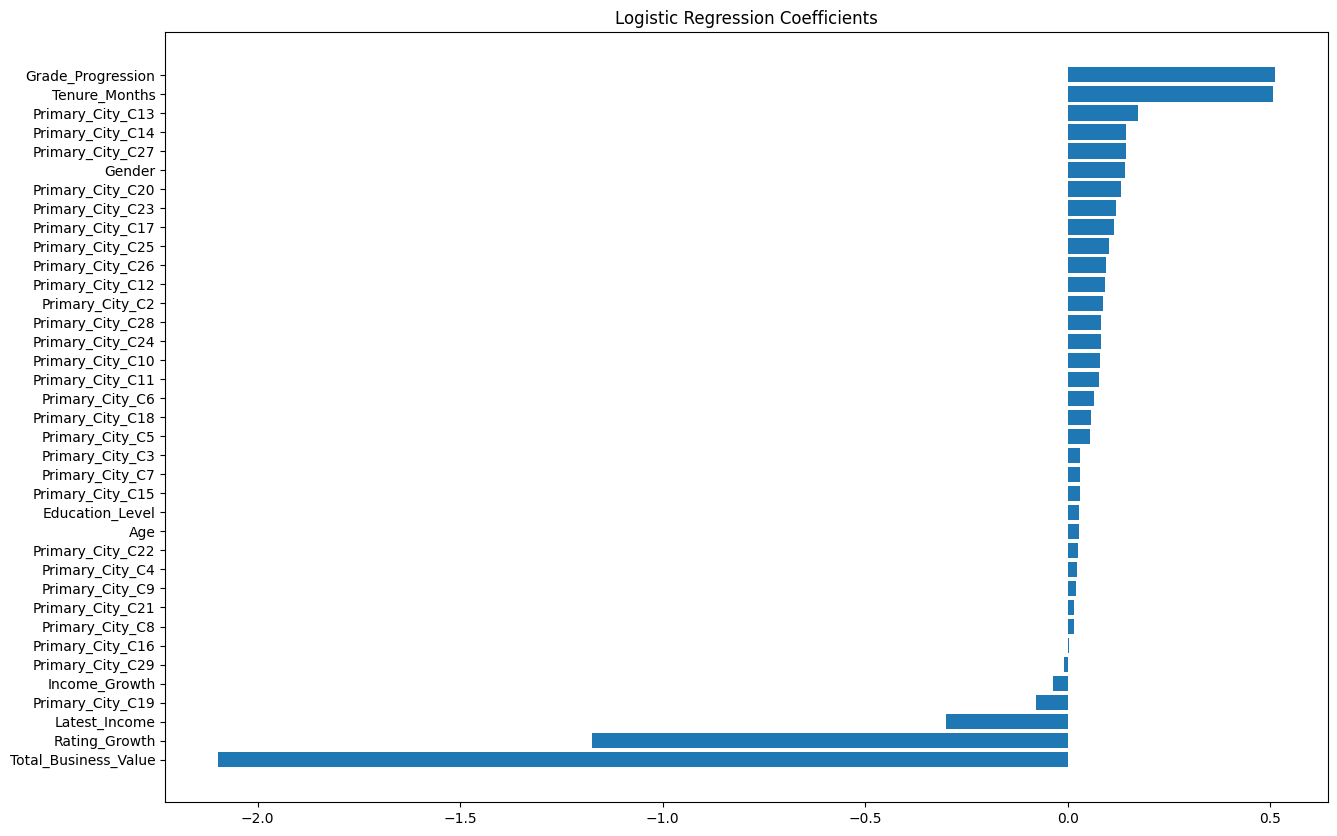

In [ ]:
coef_df = coef_df.sort_values(
    by='Coefficient'
)

plt.figure(figsize=(15,10))

plt.barh(
    coef_df['Feature'],
    coef_df['Coefficient']
)

plt.title(
    'Logistic Regression Coefficients'
)

plt.show()

**Key Drivers Influencing Driver Churn**

* Logistic Regression coefficients indicate that Total Business Value, Rating Growth, and Latest Income are the most influential factors associated with driver retention.
* Drivers generating higher business value, experiencing improvements in performance ratings, and earning higher incomes were less likely to churn.
* These findings suggest that driver engagement and retention are strongly linked to financial performance and career growth opportunities on the platform.

## **Additional Observation: Driver Tenure**
Since the positive coefficient for Tenure Months appeared inconsistent with business expectations, additional exploratory analysis is performed.

In [ ]:
driver_df.groupby(
    pd.qcut(driver_df['Tenure_Months'],4)
)['churn_flag'].mean()

/tmp/ipykernel_1575/2335212794.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  driver_df.groupby(


,churn_flag
Tenure_Months,
"(-0.001, 3.333]",0.678930
"(3.333, 7.7]",0.711636
"(7.7, 16.6]",0.753356
"(16.6, 96.267]",0.570707


* Driver attrition appears to peak during the mid-tenure stage (approximately 8-16 months), after which retention improves significantly among long-tenured drivers.

* Exploratory analysis of tenure bands revealed that churn rates decline substantially among long-tenured drivers. Drivers with more than 16 months of tenure exhibited a churn rate of approximately 57%, compared to over 75% among drivers in the mid-tenure range.

* Although the Logistic Regression coefficient for tenure was positive after controlling for other variables, the observed churn distribution suggests that long-serving drivers generally demonstrate stronger retention.

* This indicates that tenure interacts with other factors such as income, business value, and performance growth rather than acting as an isolated predictor.


# **11. Model Improvement Experiment Using SMOTE**

* Although the baseline Logistic Regression model demonstrated strong predictive performance, the target variable exhibited moderate class imbalance, with approximately 68% churned drivers and 32% active drivers.

* To evaluate whether balancing the training data could further improve churn prediction performance, Synthetic Minority Oversampling Technique (SMOTE) was applied to generate additional samples for the minority class.

## **SMOTE Training**

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)
print(y_train_smote.value_counts())

churn_flag
0    1292
1    1292
Name: count, dtype: int64


SMOTE successfully balanced the training dataset by generating synthetic observations for the minority class. As a result, both churned and active driver classes contained equal representation, reducing the potential impact of class imbalance during model training.

In [ ]:
lr_smote = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_smote.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_smote = lr_smote.predict(
    X_test_scaled
)

y_prob_smote = lr_smote.predict_proba(
    X_test_scaled
)[:,1]

## **Model Evaluation**

### **Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_smote
)

print(cm)

[[100  53]
 [ 46 278]]


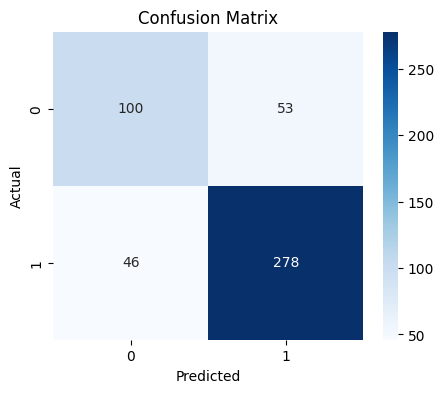

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### **Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_smote
    )
)

              precision    recall  f1-score   support

           0       0.68      0.65      0.67       153
           1       0.84      0.86      0.85       324

    accuracy                           0.79       477
   macro avg       0.76      0.76      0.76       477
weighted avg       0.79      0.79      0.79       477



### **ROC-AUC Score**

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    y_prob_smote
)

print("ROC-AUC:", round(auc,3))

ROC-AUC: 0.837


### **ROC Curve**

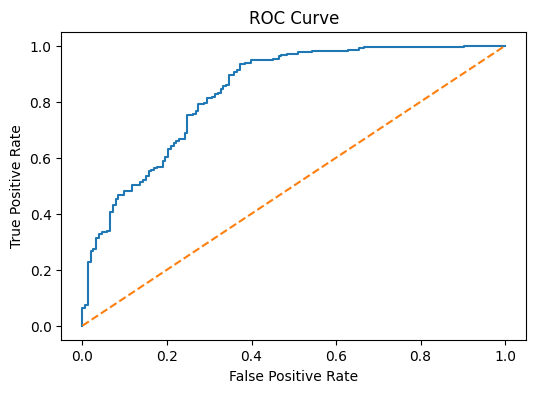

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_smote
)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

## **Feature Importance Analysis**

### **Model Coefficients**

In [ ]:
coef_df_smote = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_smote.coef_[0]
})

coef_df_smote.sort_values(
    by='Coefficient',
    ascending=False
).head(5)

,Feature,Coefficient
8,Grade_Progression,0.605732
5,Tenure_Months,0.552176
13,Primary_City_C14,0.187926
12,Primary_City_C13,0.171633
1,Gender,0.168895


In [ ]:
coef_df_smote.sort_values(
    by='Coefficient'
).head(5)

,Feature,Coefficient
4,Total_Business_Value,-2.190703
7,Rating_Growth,-1.271464
3,Latest_Income,-0.300439
6,Income_Growth,-0.028616
18,Primary_City_C19,-0.004524


### **Feature Importance Plot**

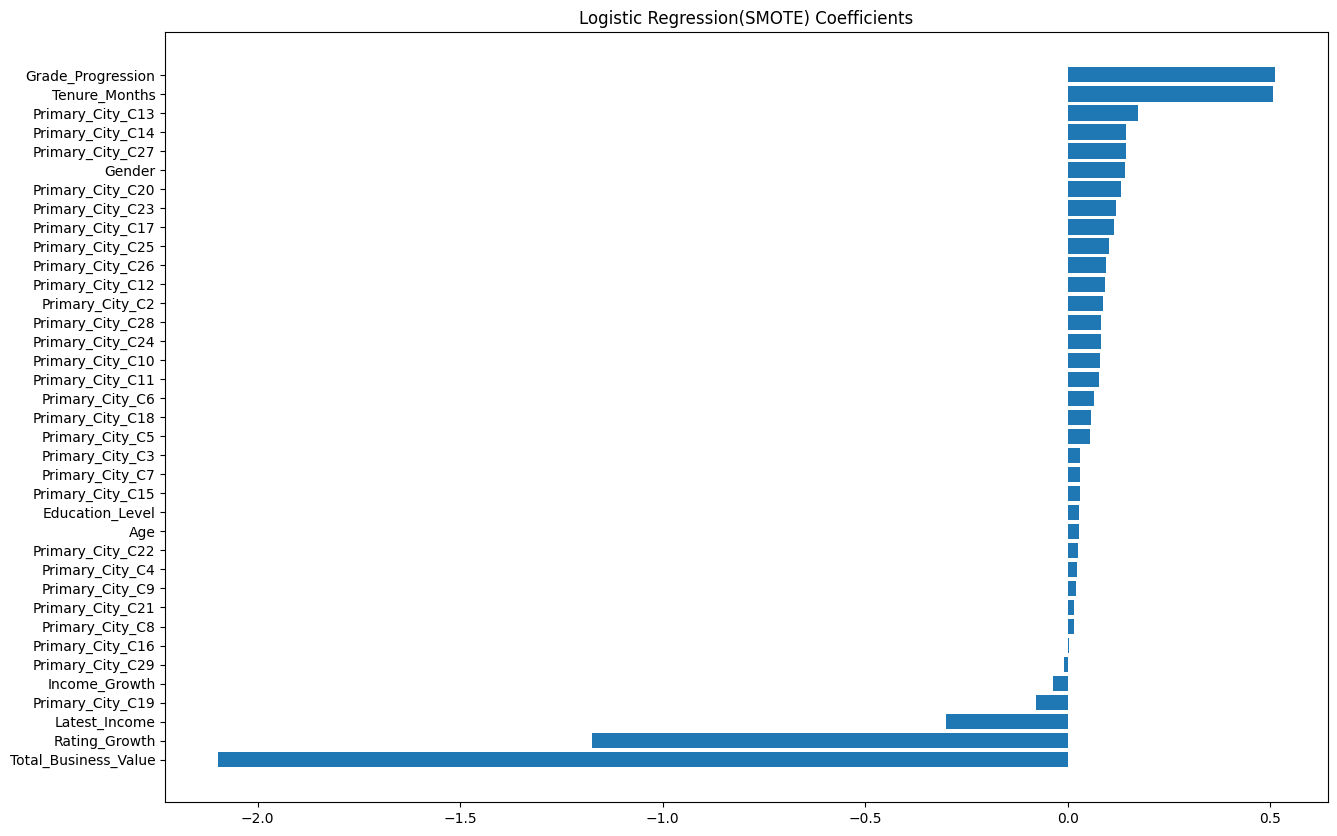

In [ ]:
coef_df_smote = coef_df_smote.sort_values(
    by='Coefficient'
)

plt.figure(figsize=(15,10))

plt.barh(
    coef_df['Feature'],
    coef_df['Coefficient']
)

plt.title(
    'Logistic Regression(SMOTE) Coefficients'
)

plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision (Churn)',
        'Recall (Churn)',
        'F1-Score (Churn)',
        'ROC-AUC'
    ],
    'Baseline': [
        0.80,
        0.85,
        0.86,
        0.85,
        0.851
    ],
    'SMOTE': [
        0.79,
        0.84,
        0.86,
        0.85,
        0.837
    ]
})

comparison_df

,Metric,Baseline,SMOTE
0,Accuracy,0.800,0.790
1,Precision (Churn),0.850,0.840
2,Recall (Churn),0.860,0.860
3,F1-Score (Churn),0.850,0.850
4,ROC-AUC,0.851,0.837


* Although SMOTE successfully balanced the training data, it did not improve model performance.

* Accuracy decreased from 80% to 79%, precision for churn prediction declined slightly, and ROC-AUC reduced from 0.851 to 0.837. Additionally, the overall feature importance ranking remained largely unchanged.

* Therefore, the baseline Logistic Regression model is retained as the final model.

## **Final Model Selection**

* A comparative assessment of the baseline and SMOTE-enhanced Logistic Regression models revealed that the baseline model consistently achieved superior overall performance.

* Although SMOTE successfully balanced the training data, it did not improve churn prediction on unseen data. Consequently, the baseline Logistic Regression model is selected as the final model for interpretation and business recommendation generation.

# **12. Business Recommendations**

### **Recommendation 1: Increase Driver Earnings**

Drivers with higher earnings were less likely to churn. Improving earning opportunities through incentives and transparent compensation policies may help strengthen driver retention.

### **Recommendation 2: Reward High-Performing Drivers**

Drivers whose ratings improved over time were less likely to leave the platform. Recognising and rewarding high-performing drivers may help improve both retention and service quality.

### **Recommendation 3: Focus Retention Efforts on Low Business-Value Drivers**

Drivers generating lower business value showed a higher likelihood of churn. Identifying and supporting these drivers early may help reduce attrition and improve long-term engagement.

### **Recommendation 4: Strengthen Retention During Mid-Tenure Period**

Churn was highest among drivers with approximately 7-16 months of tenure and decreased substantially among long-tenured drivers. Targeted retention initiatives during this critical period may help reduce driver churn.

# **13. Conclusion**

* This project aimed to identify drivers at risk of churn and understand the factors contributing to driver attrition on the Ola platform.

* The final Logistic Regression model achieved a Recall of 86%, Precision of 85%, F1-Score of 85%, and ROC-AUC of 0.851, demonstrating strong capability in identifying churned drivers and distinguishing them from active drivers.

* An additional SMOTE-based model was evaluated to address class imbalance; however, the baseline Logistic Regression model delivered superior overall performance and was therefore selected as the final solution.

* Feature importance analysis identified Total Business Value, Rating Growth, and Latest Income as the strongest retention-related factors. Tenure analysis further revealed elevated churn rates among drivers in the mid-tenure stage.

* Overall, the findings suggest that driver retention is strongly influenced by earnings, business contribution, performance growth, and engagement over time. These insights can help Ola implement targeted retention strategies and proactively reduce driver churn.
